# Experiments Results Analysis

This notebook compares the **4 final thesis experiments**:

- `exp01`: cold memory, vision on
- `exp02`: warm memory, vision on
- `exp03`: cold memory, vision off
- `exp04`: warm memory, vision off

Each analysis block has one markdown description followed by one code cell, so figures/tables can be exported directly into the thesis.

## 1) Imports and plot style

This cell imports dependencies, configures plotting style suitable for thesis figures, and defines a consistent experiment ordering.

In [ ]:
import ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='talk')
except Exception:
    sns = None

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

EXP_ORDER = ['exp01', 'exp02', 'exp03', 'exp04']
EXP_LABELS = {
    'exp01': 'Exp01 Cold + Vision ON',
    'exp02': 'Exp02 Warm + Vision ON',
    'exp03': 'Exp03 Cold + Vision OFF',
    'exp04': 'Exp04 Warm + Vision OFF',
}

EXP_FACTOR_MAP = {
    'exp01': {'memory_mode': 'cold', 'vision_mode': 'on'},
    'exp02': {'memory_mode': 'warm', 'vision_mode': 'on'},
    'exp03': {'memory_mode': 'cold', 'vision_mode': 'off'},
    'exp04': {'memory_mode': 'warm', 'vision_mode': 'off'},
}

SAVE_FIGURES = False
FIG_DIR = Path('../thesis_experiment/figures')


def savefig_thesis(name: str):
    if not SAVE_FIGURES:
        return
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    stem = re.sub(r'[^a-zA-Z0-9_\-]+', '_', name).strip('_')
    for ext in ('png', 'pdf'):
        plt.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches='tight')

def to_bool(v):
    if pd.isna(v):
        return False
    if isinstance(v, bool):
        return v
    s = str(v).strip().lower()
    return s in {'1', 'true', 'yes', 'y'}


def to_num(v):
    try:
        return float(v)
    except Exception:
        return np.nan


def parse_counter_cell(v):
    if isinstance(v, dict):
        return v
    if pd.isna(v):
        return {}
    s = str(v).strip()
    if not s:
        return {}
    try:
        out = json.loads(s)
        if isinstance(out, dict):
            return out
    except Exception:
        pass
    try:
        out = ast.literal_eval(s)
        if isinstance(out, dict):
            return out
    except Exception:
        pass
    return {}


def canonical_exp(name):
    s = str(name or '')
    m = re.search(r'(exp0[1-4])', s)
    return m.group(1) if m else 'other'


def extract_cfg_value(cfg_obj, path, default=np.nan):
    cur = cfg_obj
    for p in path:
        if not isinstance(cur, dict) or p not in cur:
            return default
        cur = cur[p]
    return cur

def infer_memory_mode(row):
    v = row.get('cfg_initialize_memory', np.nan)
    if not pd.isna(v):
        return 'cold' if bool(v) else 'warm'
    return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('memory_mode', 'unknown')


def infer_vision_mode(row):
    v = row.get('cfg_use_vision', np.nan)
    if not pd.isna(v):
        return 'on' if bool(v) else 'off'
    return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('vision_mode', 'unknown')


def wilson_ci(k, n, z=1.96):
    if n <= 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return center - half, center + half


def load_experiments_csv(force_csv_path=None, candidate_dirs=None):
    """Load experiments CSV, preferring the latest complete 4-experiment run."""
    if candidate_dirs is None:
        candidate_dirs = [Path('../thesis_experiment'), Path('thesis_experiment')]

    candidates = []
    for d in candidate_dirs:
        if d.exists():
            candidates.extend(d.glob('experiments_*.csv'))

    candidates = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError('No experiments CSV found in thesis_experiment/')

    def inspect_candidate(path: Path):
        try:
            tmp = pd.read_csv(path, encoding='utf-8-sig')
        except Exception:
            return {
                'path': str(path),
                'rows': 0,
                'mtime': path.stat().st_mtime,
                'exp_codes': [],
                'has_all_4': False,
                'tasks_per_exp_min': 0,
            }

        exp_codes = []
        if 'experiment_name' in tmp.columns:
            for x in tmp['experiment_name'].dropna().astype(str):
                m = re.search(r'(exp0[1-4])', x)
                if m:
                    exp_codes.append(m.group(1))

        exp_set = sorted(set(exp_codes))
        has_all_4 = all(e in exp_set for e in EXP_ORDER)

        tasks_per_exp_min = 0
        if 'experiment_name' in tmp.columns and 'task_id' in tmp.columns and len(tmp):
            grp = tmp.assign(exp_code=tmp['experiment_name'].astype(str).str.extract(r'(exp0[1-4])', expand=False))
            grp = grp[grp['exp_code'].isin(EXP_ORDER)]
            if len(grp):
                tasks_per_exp = grp.groupby('exp_code')['task_id'].nunique()
                tasks_per_exp_min = int(tasks_per_exp.min()) if len(tasks_per_exp) else 0

        return {
            'path': str(path),
            'rows': int(len(tmp)),
            'mtime': path.stat().st_mtime,
            'exp_codes': exp_set,
            'has_all_4': bool(has_all_4),
            'tasks_per_exp_min': tasks_per_exp_min,
        }

    meta = pd.DataFrame([inspect_candidate(p) for p in candidates])
    meta['mtime'] = pd.to_datetime(meta['mtime'], unit='s')
    meta = meta.sort_values('mtime', ascending=False)

    if force_csv_path:
        csv_path = Path(force_csv_path)
    else:
        complete = meta[meta['has_all_4']].copy()
        if len(complete):
            complete = complete.sort_values(['mtime', 'rows'], ascending=[False, False])
            csv_path = Path(complete.iloc[0]['path'])
        else:
            csv_path = Path(meta.iloc[0]['path'])

    df_raw = pd.read_csv(csv_path, encoding='utf-8-sig')
    return csv_path, df_raw, meta


def preprocess_experiments(df_raw):
    """Normalize schema and derive analysis-ready columns."""
    df = df_raw.copy()

    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    if 'success' in df.columns:
        df['success_bool'] = df['success'].map(to_bool)
    else:
        df['success_bool'] = False

    if 'status' in df.columns:
        df['status_norm'] = df['status'].astype(str).str.upper().str.strip()
    else:
        df['status_norm'] = 'UNKNOWN'

    if 'experiment_name' in df.columns:
        df['exp_name_raw'] = df['experiment_name'].fillna('unknown')
    else:
        df['exp_name_raw'] = 'unknown'

    df['exp_code'] = df['exp_name_raw'].map(canonical_exp)
    df['exp_label'] = df['exp_code'].map(EXP_LABELS).fillna(df['exp_name_raw'])

    if df['exp_code'].isin(EXP_ORDER).any():
        df = df[df['exp_code'].isin(EXP_ORDER)].copy()

    df['cfg_obj'] = [{} for _ in range(len(df))]
    if 'experiment_config_json' in df.columns:
        parsed = []
        for v in df['experiment_config_json']:
            try:
                parsed.append(json.loads(v) if isinstance(v, str) and v.strip() else {})
            except Exception:
                parsed.append({})
        df['cfg_obj'] = parsed

    df['cfg_initialize_memory'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['memory_settings', 'initialize_memory']))
    df['cfg_memory_name'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['memory_settings', 'memory_name']))
    df['cfg_use_vision'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['perception_settings', 'use_vision']))
    df['cfg_include_invisible'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['perception_settings', 'a11y_extractor_settings', 'include_invisible']))
    df['cfg_keep_only_active_window_nodes'] = df['cfg_obj'].map(
        lambda o: extract_cfg_value(o, ['perception_settings', 'a11y_extractor_settings', 'keep_only_active_window_nodes'])
    )

    df['experiment_max_cycles_num'] = df['experiment_max_cycles'].map(to_num) if 'experiment_max_cycles' in df.columns else np.nan

    numeric_cols = [
        'chunks_total', 'chunks_success', 'chunks_fail', 'chunk_success_rate', 'steps_total', 'steps_success', 'steps_fail',
        'step_success_rate', 'total_planned_pause_sec', 'avg_pause_per_step_sec', 'episode_duration_sec',
        'recovery_after_fail_rate', 'recoveries_after_fail_total', 'recoveries_after_fail_opportunities',
        'first_failure_chunk_index', 'max_consecutive_chunk_failures', 'planner_done_judge_fail', 'planner_fail_judge_success',
        'llm_requests_total',
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = df[c].map(to_num)

    for c in ['failure_type_counts', 'action_type_counts', 'decision_counts']:
        if c in df.columns:
            df[c] = df[c].map(parse_counter_cell)

    df['memory_mode'] = df.apply(infer_memory_mode, axis=1)
    df['vision_mode'] = df.apply(infer_vision_mode, axis=1)
    df['memory_label'] = df['memory_mode'].map({'cold': 'Cold', 'warm': 'Warm'}).fillna('Unknown')
    df['vision_label'] = df['vision_mode'].map({'on': 'Vision ON', 'off': 'Vision OFF'}).fillna('Vision ?')
    df['condition_2x2'] = df['memory_label'] + ' | ' + df['vision_label']

    df['exp_sort'] = df['exp_code'].apply(lambda x: EXP_ORDER.index(x) if x in EXP_ORDER else 999)
    df = df.sort_values(['exp_sort', 'timestamp'], kind='stable').reset_index(drop=True)

    print('Filtered rows:', len(df))
    print('Experiments found:', sorted(df['exp_code'].unique()))
    return df

def run_section_04_coverage(df):
    """Run coverage, missing tasks, and duplicate checks."""
    expected_tasks = int(df['experiment_tasks_total'].dropna().max()) if 'experiment_tasks_total' in df.columns and df['experiment_tasks_total'].notna().any() else 10

    coverage = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)
          .agg(
              recorded_episodes=('task_id', 'count'),
              unique_tasks=('task_id', pd.Series.nunique),
              successes=('success_bool', 'sum'),
              success_rate=('success_bool', 'mean')
          )
    )
    coverage['expected_tasks'] = expected_tasks
    coverage['missing_rows_vs_expected'] = coverage['expected_tasks'] - coverage['recorded_episodes']
    coverage['missing_unique_tasks'] = coverage['expected_tasks'] - coverage['unique_tasks']
    coverage = coverage.sort_values('exp_code')

    display(coverage)

    dups = (
        df.groupby(['exp_code', 'task_id']).size().reset_index(name='n')
          .query('n > 1')
          .sort_values(['exp_code', 'n'], ascending=[True, False])
    )
    print('Duplicate task rows per experiment:' if len(dups) else 'No duplicated task rows per experiment.')
    if len(dups):
        display(dups)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_cov = coverage.copy()
    plot_cov['exp_label_short'] = plot_cov['exp_code'].map(EXP_LABELS)
    ax.bar(plot_cov['exp_label_short'], plot_cov['recorded_episodes'], label='Recorded episodes')
    ax.plot(plot_cov['exp_label_short'], plot_cov['expected_tasks'], color='black', marker='o', linestyle='--', label='Expected tasks')
    ax.set_ylabel('Episodes')
    ax.set_title('Run Coverage by Experiment')
    ax.legend()
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()


def run_section_05_settings_table(df):
    """Final experiment settings summary and LaTeX export."""
    settings_table = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)
          .agg(
              max_cycles=('experiment_max_cycles_num', 'max'),
              initialize_memory=('cfg_initialize_memory', 'first'),
              memory_name=('cfg_memory_name', 'first'),
              use_vision=('cfg_use_vision', 'first'),
              include_invisible=('cfg_include_invisible', 'first'),
              keep_only_active_window_nodes=('cfg_keep_only_active_window_nodes', 'first')
          )
          .sort_values('exp_code')
    )

    def mem_mode(v):
        if pd.isna(v):
            return 'unknown'
        return 'cold (reset)' if bool(v) else 'warm (reuse)'

    settings_table['memory_mode'] = settings_table['initialize_memory'].map(mem_mode)
    settings_table = settings_table[[
        'exp_code', 'exp_label', 'max_cycles', 'memory_mode', 'memory_name',
        'use_vision', 'include_invisible', 'keep_only_active_window_nodes'
    ]]

    display(settings_table)

    latex_settings = settings_table.rename(columns={
        'exp_code': 'Experiment',
        'max_cycles': 'Max cycles',
        'memory_mode': 'Memory',
        'use_vision': 'Use vision',
        'include_invisible': 'Include invisible',
        'keep_only_active_window_nodes': 'Only active window nodes'
    }).to_latex(index=False, escape=True)

    print(latex_settings)


def run_section_06_osworld_success(df):
    """OSWorld success comparison across experiments."""
    osw_summary = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)
          .agg(
              tasks=('task_id', 'count'),
              successes=('success_bool', 'sum')
          )
    )
    osw_summary['success_rate'] = osw_summary['successes'] / osw_summary['tasks'].replace(0, np.nan)
    osw_summary = osw_summary.sort_values('exp_code')

    display(osw_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(osw_summary['exp_label'], osw_summary['success_rate'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Success rate')
    ax.set_title('OSWorld Task Success Rate by Experiment')
    plt.xticks(rotation=20, ha='right')
    for i, r in osw_summary.reset_index(drop=True).iterrows():
        ax.text(i, r['success_rate'] + 0.02, f"{int(r['successes'])}/{int(r['tasks'])}", ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()


def run_section_07_chunk_metrics(df):
    """Chunk-level control metrics."""
    chunk_cols = ['chunks_total', 'chunks_success', 'chunks_fail', 'chunk_success_rate']
    chunk_available = [c for c in chunk_cols if c in df.columns]

    chunk_summary = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)[chunk_available]
          .mean(numeric_only=True)
          .sort_values('exp_code')
    )

    display(chunk_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(chunk_summary['exp_label'], chunk_summary['chunks_success'], label='chunks_success')
    axes[0].bar(chunk_summary['exp_label'], chunk_summary['chunks_fail'], bottom=chunk_summary['chunks_success'], label='chunks_fail')
    axes[0].set_title('Average Chunks per Episode')
    axes[0].set_ylabel('Chunks')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(chunk_summary['exp_label'], chunk_summary['chunk_success_rate'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Chunk Success Rate ($r_c$)')
    axes[1].set_ylabel('Rate')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


def run_section_08_failure_dynamics(df):
    """Failure dynamics inside episodes."""
    dyn_cols = [c for c in ['first_failure_chunk_index', 'max_consecutive_chunk_failures'] if c in df.columns]
    dyn = df[['exp_code', 'exp_label'] + dyn_cols].copy()

    display(
        dyn.groupby(['exp_code', 'exp_label'], as_index=False)[dyn_cols].mean(numeric_only=True).sort_values('exp_code')
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, col, ttl in [
        (axes[0], 'first_failure_chunk_index', 'First Failure Chunk Index'),
        (axes[1], 'max_consecutive_chunk_failures', 'Max Consecutive Chunk Failures'),
    ]:
        if col not in dyn.columns:
            ax.axis('off')
            continue
        if sns is not None:
            sns.boxplot(data=dyn, x='exp_label', y=col, ax=ax, showfliers=False)
            sns.stripplot(data=dyn, x='exp_label', y=col, ax=ax, color='black', alpha=0.5, size=4)
        else:
            for i, g in enumerate(EXP_ORDER):
                vals = dyn.loc[dyn['exp_code'] == g, col].dropna().values
                if len(vals):
                    ax.scatter(np.full_like(vals, i, dtype=float), vals, alpha=0.6)
            ax.set_xticks(range(len(EXP_ORDER)))
            ax.set_xticklabels([EXP_LABELS[e] for e in EXP_ORDER], rotation=20, ha='right')
        ax.set_title(ttl)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


def run_section_09_step_metrics(df):
    """Step-level execution metrics."""
    step_cols = [c for c in ['steps_total', 'steps_success', 'steps_fail', 'step_success_rate'] if c in df.columns]
    step_summary = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)[step_cols]
          .mean(numeric_only=True)
          .sort_values('exp_code')
    )

    display(step_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(step_summary['exp_label'], step_summary['steps_success'], label='steps_success')
    axes[0].bar(step_summary['exp_label'], step_summary['steps_fail'], bottom=step_summary['steps_success'], label='steps_fail')
    axes[0].set_title('Average Evaluated Steps per Episode')
    axes[0].set_ylabel('Steps')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(step_summary['exp_label'], step_summary['step_success_rate'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Step Success Rate ($r_s$)')
    axes[1].set_ylabel('Rate')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


def run_section_10_action_distribution(df):
    """Action type composition (PYTHON/WAIT)."""
    if 'action_type_counts' not in df.columns:
        raise ValueError('action_type_counts column not found in CSV')

    rows = []
    for _, r in df[['exp_code', 'exp_label', 'action_type_counts']].iterrows():
        d = r['action_type_counts'] if isinstance(r['action_type_counts'], dict) else {}
        for k, v in d.items():
            rows.append({'exp_code': r['exp_code'], 'exp_label': r['exp_label'], 'action_type': str(k).upper(), 'count': float(v)})

    act = pd.DataFrame(rows)
    if act.empty:
        print('No action_type_counts data available.')
    else:
        act_sum = act.groupby(['exp_code', 'exp_label', 'action_type'], as_index=False)['count'].sum()
        pivot = act_sum.pivot_table(index=['exp_code', 'exp_label'], columns='action_type', values='count', fill_value=0)
        pivot = pivot.reset_index().sort_values('exp_code')
        action_cols = [c for c in pivot.columns if c not in {'exp_code', 'exp_label'}]
        pivot['total'] = pivot[action_cols].sum(axis=1)
        for c in action_cols:
            pivot[f'{c}_share'] = np.where(pivot['total'] > 0, pivot[c] / pivot['total'], 0)

        display(pivot)

        share_cols = [c for c in pivot.columns if c.endswith('_share')]
        fig, ax = plt.subplots(figsize=(11, 5))
        bottom = np.zeros(len(pivot))
        for c in share_cols:
            ax.bar(pivot['exp_label'], pivot[c], bottom=bottom, label=c.replace('_share', ''))
            bottom += pivot[c].values
        ax.set_ylim(0, 1)
        ax.set_ylabel('Share')
        ax.set_title('Action Type Composition')
        ax.legend(loc='upper right', ncol=3)
        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        plt.show()


def run_section_11_timing(df):
    """Timing proxies and distributions."""
    timing_cols = [c for c in ['episode_duration_sec', 'total_planned_pause_sec', 'avg_pause_per_step_sec'] if c in df.columns]

    summary_timing = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)[timing_cols]
          .mean(numeric_only=True)
          .sort_values('exp_code')
    )

    display(summary_timing)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (col, title, ylab) in enumerate([
        ('episode_duration_sec', 'Episode Duration', 'seconds'),
        ('total_planned_pause_sec', 'Total Planned Pause ($P_{tot}$)', 'seconds'),
        ('avg_pause_per_step_sec', 'Average Pause per Step ($\\bar{p}$)', 'seconds'),
    ]):
        if col not in df.columns:
            axes[i].axis('off')
            continue
        if sns is not None:
            sns.boxplot(data=df, x='exp_label', y=col, ax=axes[i], showfliers=False)
            sns.stripplot(data=df, x='exp_label', y=col, ax=axes[i], color='black', alpha=0.4, size=3)
        else:
            for j, e in enumerate(EXP_ORDER):
                vals = df.loc[df['exp_code'] == e, col].dropna().values
                if len(vals):
                    axes[i].scatter(np.full_like(vals, j, dtype=float), vals, alpha=0.6)
            axes[i].set_xticks(range(len(EXP_ORDER)))
            axes[i].set_xticklabels([EXP_LABELS[e] for e in EXP_ORDER], rotation=20, ha='right')
        axes[i].set_title(title)
        axes[i].set_ylabel(ylab)
        axes[i].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


def run_section_12_recovery(df):
    """Recovery dynamics after failures."""
    rec_cols = [c for c in ['recoveries_after_fail_total', 'recoveries_after_fail_opportunities', 'recovery_after_fail_rate'] if c in df.columns]
    rec_summary = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)[rec_cols]
          .mean(numeric_only=True)
          .sort_values('exp_code')
    )

    display(rec_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(rec_summary['exp_label'], rec_summary['recoveries_after_fail_total'], label='recoveries total')
    axes[0].bar(
        rec_summary['exp_label'],
        rec_summary['recoveries_after_fail_opportunities'] - rec_summary['recoveries_after_fail_total'],
        bottom=rec_summary['recoveries_after_fail_total'],
        label='non-recovered opportunities'
    )
    axes[0].set_title('Recovery Opportunities vs Successful Recoveries')
    axes[0].set_ylabel('count')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(rec_summary['exp_label'], rec_summary['recovery_after_fail_rate'])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Recovery Rate ($r_{rec}$)')
    axes[1].set_ylabel('rate')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


def run_section_13_termination(df):
    """Termination awareness metrics and plots."""
    term = df[['exp_code', 'exp_label', 'status_norm', 'success_bool']].copy()
    term['false_positive_done'] = (term['status_norm'] == 'DONE') & (~term['success_bool'])
    term['false_negative_fail'] = (term['status_norm'] == 'FAIL') & (term['success_bool'])
    term['error_status'] = term['status_norm'] == 'ERROR'

    term_summary = (
        term.groupby(['exp_code', 'exp_label'], as_index=False)
            .agg(
                episodes=('status_norm', 'count'),
                false_positive_done=('false_positive_done', 'sum'),
                false_negative_fail=('false_negative_fail', 'sum'),
                errors=('error_status', 'sum')
            )
            .sort_values('exp_code')
    )

    for c in ['false_positive_done', 'false_negative_fail', 'errors']:
        term_summary[f'{c}_rate'] = term_summary[c] / term_summary['episodes'].replace(0, np.nan)

    term_summary['termination_mismatch_count'] = (
        term_summary['false_positive_done'] + term_summary['false_negative_fail'] + term_summary['errors']
    )
    term_summary['termination_mismatch_rate'] = (
        term_summary['termination_mismatch_count'] / term_summary['episodes'].replace(0, np.nan)
    )
    term_summary['termination_consistency_rate'] = 1 - term_summary['termination_mismatch_rate']

    all_zero = bool((term_summary['termination_mismatch_count'].fillna(0) == 0).all())
    if all_zero:
        print('No termination mismatches found in this run (all experiments at 0 mismatches).')

    display(term_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: mismatch rates (still useful if non-zero)
    plot_cols = ['false_positive_done_rate', 'false_negative_fail_rate', 'errors_rate']
    plot_df = term_summary.melt(id_vars=['exp_label'], value_vars=plot_cols, var_name='metric', value_name='rate')
    if sns is not None:
        sns.barplot(data=plot_df, x='exp_label', y='rate', hue='metric', ax=axes[0])
    else:
        for m in plot_cols:
            sub = plot_df[plot_df['metric'] == m]
            axes[0].plot(sub['exp_label'], sub['rate'], marker='o', label=m)
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Termination Mismatch Components')
    axes[0].set_ylabel('Rate')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend(title='')

    # Right: positive view (consistency)
    axes[1].bar(term_summary['exp_label'], term_summary['termination_consistency_rate'], color='#2ca02c')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Termination Consistency Rate')
    axes[1].set_ylabel('Rate')
    axes[1].tick_params(axis='x', rotation=20)
    for i, r in term_summary.reset_index(drop=True).iterrows():
        txt = f"{int(r['episodes'] - r['termination_mismatch_count'])}/{int(r['episodes'])}"
        axes[1].text(i, min(1.0, r['termination_consistency_rate'] + 0.02), txt, ha='center', fontsize=10)

    plt.tight_layout()
    savefig_thesis('termination_awareness_dual_view')
    plt.show()


def run_section_14_alignment(df):
    """Planner-Judge alignment analysis."""
    align_cols = [c for c in ['planner_done_judge_fail', 'planner_fail_judge_success'] if c in df.columns]
    if not align_cols:
        raise ValueError('Alignment columns not found in CSV.')

    align_summary = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)[align_cols]
          .sum(numeric_only=True)
          .sort_values('exp_code')
    )

    if 'chunks_total' in df.columns:
        chunk_base = df.groupby(['exp_code', 'exp_label'], as_index=False)['chunks_total'].sum(numeric_only=True)
        align_summary = align_summary.merge(chunk_base, on=['exp_code', 'exp_label'], how='left')
        denom = align_summary['chunks_total'].replace(0, np.nan)
    else:
        # fallback denominator: episodes
        epi_base = df.groupby(['exp_code', 'exp_label'], as_index=False)['task_id'].count().rename(columns={'task_id': 'chunks_total'})
        align_summary = align_summary.merge(epi_base, on=['exp_code', 'exp_label'], how='left')
        denom = align_summary['chunks_total'].replace(0, np.nan)

    align_summary['planner_judge_mismatch_total'] = align_summary[align_cols].sum(axis=1)
    align_summary['planner_judge_mismatch_per_chunk'] = align_summary['planner_judge_mismatch_total'] / denom
    align_summary['planner_judge_alignment_rate'] = 1 - align_summary['planner_judge_mismatch_per_chunk']

    all_zero = bool((align_summary['planner_judge_mismatch_total'].fillna(0) == 0).all())
    if all_zero:
        print('No planner-judge mismatches found in this run.')

    display(align_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: mismatch components counts
    plot_align = align_summary.melt(id_vars=['exp_label'], value_vars=align_cols, var_name='metric', value_name='count')
    if sns is not None:
        sns.barplot(data=plot_align, x='exp_label', y='count', hue='metric', ax=axes[0])
    else:
        for m in align_cols:
            sub = plot_align[plot_align['metric'] == m]
            axes[0].plot(sub['exp_label'], sub['count'], marker='o', label=m)
    axes[0].set_title('Planner--Judge Mismatch Counts')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend(title='')

    # Right: alignment quality
    axes[1].bar(align_summary['exp_label'], align_summary['planner_judge_alignment_rate'], color='#2ca02c')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Planner--Judge Alignment Rate (1 - mismatch/chunk)')
    axes[1].set_ylabel('Rate')
    axes[1].tick_params(axis='x', rotation=20)
    for i, r in align_summary.reset_index(drop=True).iterrows():
        axes[1].text(i, min(1.0, r['planner_judge_alignment_rate'] + 0.02), f"m={int(r['planner_judge_mismatch_total'])}", ha='center', fontsize=10)

    plt.tight_layout()
    savefig_thesis('planner_judge_alignment_dual_view')
    plt.show()


def run_section_15_failure_types(df):
    """Failure type composition (stacked shares)."""
    if 'failure_type_counts' not in df.columns:
        raise ValueError('failure_type_counts column not found in CSV')

    rows = []
    for _, r in df[['exp_code', 'exp_label', 'failure_type_counts']].iterrows():
        d = r['failure_type_counts'] if isinstance(r['failure_type_counts'], dict) else {}
        for k, v in d.items():
            rows.append({'exp_code': r['exp_code'], 'exp_label': r['exp_label'], 'failure_type': str(k), 'count': float(v)})

    ft = pd.DataFrame(rows)
    if ft.empty:
        print('No failure_type_counts data available.')
    else:
        ft_sum = ft.groupby(['exp_code', 'exp_label', 'failure_type'], as_index=False)['count'].sum()
        ft_pivot = ft_sum.pivot_table(index=['exp_code', 'exp_label'], columns='failure_type', values='count', fill_value=0)
        ft_pivot = ft_pivot.reset_index().sort_values('exp_code')
        type_cols = [c for c in ft_pivot.columns if c not in {'exp_code', 'exp_label'}]
        ft_pivot['total'] = ft_pivot[type_cols].sum(axis=1)
        for c in type_cols:
            ft_pivot[f'{c}_share'] = np.where(ft_pivot['total'] > 0, ft_pivot[c] / ft_pivot['total'], 0)

        display(ft_pivot)

        share_cols = [c for c in ft_pivot.columns if c.endswith('_share')]
        fig, ax = plt.subplots(figsize=(12, 5))
        bottom = np.zeros(len(ft_pivot))
        for c in share_cols:
            ax.bar(ft_pivot['exp_label'], ft_pivot[c], bottom=bottom, label=c.replace('_share', ''))
            bottom += ft_pivot[c].values
        ax.set_ylim(0, 1)
        ax.set_ylabel('share')
        ax.set_title('Failure Type Composition')
        ax.legend(loc='upper right', ncol=3)
        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        plt.show()


def run_section_16_task_heatmap(df):
    """Task-level success heatmap."""
    task_meta = {}
    task_candidates = [Path('../thesis_experiment/tasks.json'), Path('thesis_experiment/tasks.json')]
    task_path = next((p for p in task_candidates if p.exists()), None)

    if task_path is not None:
        tasks_obj = json.loads(task_path.read_text(encoding='utf-8-sig'))
        for t in tasks_obj:
            tid = str(t.get('id'))
            task_meta[tid] = str(t.get('instruction', ''))

    heat_df = (
        df.groupby(['exp_code', 'task_id'], as_index=False)['success_bool']
          .max()  # if duplicated rows exist, treat task as solved if any row solved.
    )

    if heat_df.empty:
        print('No task-level data available.')
    else:
        heat = heat_df.pivot(index='task_id', columns='exp_code', values='success_bool').fillna(0).astype(int)
        heat = heat.reindex(columns=[e for e in EXP_ORDER if e in heat.columns])
        heat.index = [f"{tid[:8]} | {task_meta.get(tid, '')[:60]}" for tid in heat.index]

        plt.figure(figsize=(13, max(5, 0.58 * len(heat))))
        if sns is not None:
            sns.heatmap(heat, annot=True, fmt='d', cmap='RdYlGn', cbar=False, linewidths=0.4)
        else:
            plt.imshow(heat.values, aspect='auto')
            plt.xticks(range(len(heat.columns)), heat.columns)
            plt.yticks(range(len(heat.index)), heat.index)
        plt.title('Task-level Success (1=success, 0=failure)')
        plt.xlabel('Experiment')
        plt.ylabel('Task')
        plt.tight_layout()
        savefig_thesis('task_level_success_heatmap')
        plt.show()


def run_section_17_final_table(df):
    """Final compact thesis table and LaTeX export."""
    final_cols = {
        'success_bool': 'osworld_success_rate',
        'chunk_success_rate': 'chunk_success_rate_mean',
        'step_success_rate': 'step_success_rate_mean',
        'episode_duration_sec': 'episode_duration_sec_mean',
        'total_planned_pause_sec': 'total_planned_pause_sec_mean',
        'avg_pause_per_step_sec': 'avg_pause_per_step_sec_mean',
        'recovery_after_fail_rate': 'recovery_after_fail_rate_mean',
        'first_failure_chunk_index': 'first_failure_chunk_index_mean',
        'max_consecutive_chunk_failures': 'max_consecutive_chunk_failures_mean',
    }

    available = [c for c in final_cols.keys() if c in df.columns]
    final_table = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)[available]
          .mean(numeric_only=True)
          .rename(columns=final_cols)
          .sort_values('exp_code')
    )

    # add completion info
    comp = (
        df.groupby(['exp_code', 'exp_label'], as_index=False)
          .agg(tasks=('task_id', 'count'), successes=('success_bool', 'sum'))
    )
    final_table = final_table.merge(comp, on=['exp_code', 'exp_label'], how='left')

    # rounding for readability
    for c in final_table.columns:
        if c.endswith('_rate') or c.endswith('_mean'):
            final_table[c] = final_table[c].round(3)

    display(final_table)

    latex_final = final_table.rename(columns={
        'exp_code': 'Experiment',
        'exp_label': 'Condition',
        'tasks': 'Episodes',
        'successes': 'Successes'
    }).to_latex(index=False, escape=True)

    print(latex_final)


def run_section_18_factorized_view(df):
    """2x2 factorized coverage snapshot."""
    def infer_memory_mode(row):
        v = row.get('cfg_initialize_memory', np.nan)
        if not pd.isna(v):
            return 'cold' if bool(v) else 'warm'
        return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('memory_mode', 'unknown')


    def infer_vision_mode(row):
        v = row.get('cfg_use_vision', np.nan)
        if not pd.isna(v):
            return 'on' if bool(v) else 'off'
        return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('vision_mode', 'unknown')


    if 'llm_requests_total' in df.columns:
        df['llm_requests_total'] = df['llm_requests_total'].map(to_num)

    df['memory_mode'] = df.apply(infer_memory_mode, axis=1)
    df['vision_mode'] = df.apply(infer_vision_mode, axis=1)

    df['memory_label'] = df['memory_mode'].map({'cold': 'Cold', 'warm': 'Warm'}).fillna('Unknown')
    df['vision_label'] = df['vision_mode'].map({'on': 'Vision ON', 'off': 'Vision OFF'}).fillna('Vision ?')
    df['condition_2x2'] = df['memory_label'] + ' | ' + df['vision_label']

    coverage_2x2 = (
        df.groupby(['vision_label', 'memory_label'], as_index=False)
          .agg(
              episodes=('task_id', 'count'),
              unique_tasks=('task_id', pd.Series.nunique),
              successes=('success_bool', 'sum'),
          )
    )
    coverage_2x2['success_rate'] = coverage_2x2['successes'] / coverage_2x2['episodes'].replace(0, np.nan)

    print('2x2 coverage snapshot:')
    display(coverage_2x2.sort_values(['vision_label', 'memory_label']))


def run_section_19_success_ci(df):
    """OSWorld success rate with Wilson CI and interaction plot."""
    def wilson_ci(k, n, z=1.96):
        if n <= 0:
            return np.nan, np.nan
        p = k / n
        denom = 1 + z**2 / n
        center = (p + z**2 / (2*n)) / denom
        half = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
        return center - half, center + half


    osw_ci = (
        df.groupby(['exp_code', 'exp_label', 'vision_label', 'memory_label'], as_index=False)
          .agg(tasks=('task_id', 'count'), successes=('success_bool', 'sum'))
    )
    osw_ci['success_rate'] = osw_ci['successes'] / osw_ci['tasks'].replace(0, np.nan)

    lows, highs = [], []
    for _, r in osw_ci.iterrows():
        lo, hi = wilson_ci(float(r['successes']), float(r['tasks']))
        lows.append(lo)
        highs.append(hi)
    osw_ci['ci_low'] = lows
    osw_ci['ci_high'] = highs
    osw_ci = osw_ci.sort_values('exp_code')

    display(osw_ci[['exp_code', 'exp_label', 'tasks', 'successes', 'success_rate', 'ci_low', 'ci_high']])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: per-experiment bar + CI
    x = np.arange(len(osw_ci))
    y = osw_ci['success_rate'].values
    err_low = y - osw_ci['ci_low'].values
    err_high = osw_ci['ci_high'].values - y
    axes[0].bar(x, y, color=['#4C78A8', '#72B7B2', '#F58518', '#E45756'])
    axes[0].errorbar(x, y, yerr=[err_low, err_high], fmt='none', ecolor='black', capsize=5, lw=1.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(osw_ci['exp_code'].values)
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('Success rate')
    axes[0].set_title('OSWorld Success Rate (95% CI)')
    for i, r in osw_ci.reset_index(drop=True).iterrows():
        axes[0].text(i, r['success_rate'] + 0.03, f"{int(r['successes'])}/{int(r['tasks'])}", ha='center', fontsize=10)

    # Right: interaction plot (memory x vision)
    inter = (
        df.groupby(['vision_label', 'memory_label'], as_index=False)
          .agg(tasks=('task_id', 'count'), successes=('success_bool', 'sum'))
    )
    inter['success_rate'] = inter['successes'] / inter['tasks'].replace(0, np.nan)

    mem_order = ['Cold', 'Warm']
    vis_order = ['Vision ON', 'Vision OFF']
    for v in vis_order:
        sub = inter[inter['vision_label'] == v].copy()
        sub['memory_label'] = pd.Categorical(sub['memory_label'], categories=mem_order, ordered=True)
        sub = sub.sort_values('memory_label')
        axes[1].plot(sub['memory_label'], sub['success_rate'], marker='o', linewidth=2.5, label=v)

    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Success rate')
    axes[1].set_title('Memory x Vision Interaction on Success')
    axes[1].legend(title='')
    axes[1].yaxis.set_major_locator(MaxNLocator(6))

    plt.tight_layout()
    savefig_thesis('success_rate_ci_and_interaction')
    plt.show()


def run_section_20_paired_outcomes(df):
    """Warm-vs-cold paired task outcomes."""
    pair_specs = [
        ('Vision ON', 'exp01', 'exp02'),
        ('Vision OFF', 'exp03', 'exp04'),
    ]

    pair_rows = []
    for pair_label, cold_exp, warm_exp in pair_specs:
        cold = (
            df[df['exp_code'] == cold_exp][['task_id', 'success_bool']]
            .drop_duplicates(subset=['task_id'], keep='last')
            .rename(columns={'success_bool': 'cold_success'})
        )
        warm = (
            df[df['exp_code'] == warm_exp][['task_id', 'success_bool']]
            .drop_duplicates(subset=['task_id'], keep='last')
            .rename(columns={'success_bool': 'warm_success'})
        )

        merged = cold.merge(warm, on='task_id', how='inner')
        merged['pair_label'] = pair_label

        def classify(r):
            c, w = bool(r['cold_success']), bool(r['warm_success'])
            if c and w:
                return 'both_success'
            if c and not w:
                return 'cold_only_success'
            if (not c) and w:
                return 'warm_only_success'
            return 'both_fail'

        merged['outcome'] = merged.apply(classify, axis=1)
        pair_rows.append(merged)

    pair_task_cmp = pd.concat(pair_rows, ignore_index=True) if pair_rows else pd.DataFrame()

    if pair_task_cmp.empty:
        print('No task-overlap data for paired comparison.')
    else:
        paired_counts = (
            pair_task_cmp.groupby(['pair_label', 'outcome'], as_index=False)
            .size()
            .rename(columns={'size': 'count'})
        )

        display(
            paired_counts.pivot(index='pair_label', columns='outcome', values='count').fillna(0).astype(int)
        )

        order = ['both_success', 'cold_only_success', 'warm_only_success', 'both_fail']
        colors = {
            'both_success': '#2ca02c',
            'cold_only_success': '#1f77b4',
            'warm_only_success': '#ff7f0e',
            'both_fail': '#d62728',
        }

        fig, ax = plt.subplots(figsize=(11, 5))
        base = np.zeros(pair_task_cmp['pair_label'].nunique())
        labels = sorted(pair_task_cmp['pair_label'].unique())

        for o in order:
            vals = []
            for lab in labels:
                m = paired_counts[(paired_counts['pair_label'] == lab) & (paired_counts['outcome'] == o)]
                vals.append(int(m['count'].iloc[0]) if len(m) else 0)
            ax.bar(labels, vals, bottom=base, label=o, color=colors[o])
            base += np.array(vals)

        ax.set_ylabel('Tasks')
        ax.set_title('Paired Warm-vs-Cold Outcomes (Task-Matched)')
        ax.legend(title='Outcome', loc='upper right')
        plt.tight_layout()
        savefig_thesis('paired_warm_cold_outcomes')
        plt.show()


def run_section_21_paired_deltas(df):
    """Warm-vs-cold paired metric deltas."""
    if 'llm_requests_total' in df.columns:
        df['llm_requests_total'] = df['llm_requests_total'].map(to_num)

    df['success_num'] = df['success_bool'].astype(int)

    metric_specs = [
        ('success_num', 'Task success (0/1)'),
        ('chunk_success_rate', 'Chunk success rate'),
        ('step_success_rate', 'Step success rate'),
        ('episode_duration_sec', 'Episode duration (sec)'),
        ('llm_requests_total', 'LLM requests'),
    ]
    metric_specs = [(m, t) for (m, t) in metric_specs if m in df.columns]

    rows = []
    for pair_label, cold_exp, warm_exp in [('Vision ON', 'exp01', 'exp02'), ('Vision OFF', 'exp03', 'exp04')]:
        base_cols = ['task_id'] + [m for m, _ in metric_specs]

        cold = (
            df[df['exp_code'] == cold_exp][base_cols]
            .drop_duplicates(subset=['task_id'], keep='last')
            .rename(columns={m: f'{m}_cold' for m, _ in metric_specs})
        )
        warm = (
            df[df['exp_code'] == warm_exp][base_cols]
            .drop_duplicates(subset=['task_id'], keep='last')
            .rename(columns={m: f'{m}_warm' for m, _ in metric_specs})
        )

        merged = cold.merge(warm, on='task_id', how='inner')

        for m, title in metric_specs:
            delta = merged[f'{m}_warm'] - merged[f'{m}_cold']
            for tid, dv in zip(merged['task_id'], delta):
                rows.append({
                    'pair_label': pair_label,
                    'task_id': tid,
                    'metric': m,
                    'metric_title': title,
                    'delta_warm_minus_cold': float(dv) if pd.notna(dv) else np.nan,
                })

    paired_delta = pd.DataFrame(rows)

    if paired_delta.empty:
        print('No paired deltas available.')
    else:
        delta_summary = (
            paired_delta.groupby(['pair_label', 'metric_title'], as_index=False)['delta_warm_minus_cold']
            .agg(['mean', 'median'])
            .reset_index()
        )
        display(delta_summary)

        n = len(metric_specs)
        ncols = 2
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, (m, title) in enumerate(metric_specs):
            ax = axes[i]
            sub = paired_delta[paired_delta['metric'] == m].copy()

            if sns is not None:
                sns.boxplot(data=sub, x='pair_label', y='delta_warm_minus_cold', ax=ax, showfliers=False)
                sns.stripplot(data=sub, x='pair_label', y='delta_warm_minus_cold', ax=ax, color='black', alpha=0.55, size=4)
            else:
                for j, lab in enumerate(sorted(sub['pair_label'].unique())):
                    vals = sub.loc[sub['pair_label'] == lab, 'delta_warm_minus_cold'].dropna().values
                    ax.scatter(np.full_like(vals, j, dtype=float), vals, alpha=0.65)
                labs = sorted(sub['pair_label'].unique())
                ax.set_xticks(range(len(labs)))
                ax.set_xticklabels(labs)

            ax.axhline(0, color='black', linestyle='--', linewidth=1)
            ax.set_title(f"Delta (Warm - Cold): {title}")
            ax.set_xlabel('')
            ax.set_ylabel('Delta')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        savefig_thesis('paired_metric_deltas_warm_minus_cold')
        plt.show()


def run_section_22_efficiency_frontier(df):
    """Efficiency vs effectiveness frontier."""
    agg = (
        df.groupby(['exp_code', 'exp_label', 'vision_label', 'memory_label'], as_index=False)
          .agg(
              success_rate=('success_bool', 'mean'),
              avg_llm_requests=('llm_requests_total', 'mean'),
              avg_duration_sec=('episode_duration_sec', 'mean'),
              avg_chunk_success=('chunk_success_rate', 'mean'),
              avg_step_success=('step_success_rate', 'mean'),
          )
          .sort_values('exp_code')
    )

    display(agg)

    marker_map = {'Cold': 'o', 'Warm': 's'}
    color_map = {'Vision ON': '#1f77b4', 'Vision OFF': '#d62728'}

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for _, r in agg.iterrows():
        m = marker_map.get(r['memory_label'], 'o')
        c = color_map.get(r['vision_label'], 'gray')

        axes[0].scatter(r['avg_llm_requests'], r['success_rate'], s=170, marker=m, color=c, edgecolor='black', linewidth=0.7)
        axes[0].annotate(r['exp_code'], (r['avg_llm_requests'], r['success_rate']), xytext=(6, 6), textcoords='offset points', fontsize=9)

        axes[1].scatter(r['avg_duration_sec'], r['success_rate'], s=170, marker=m, color=c, edgecolor='black', linewidth=0.7)
        axes[1].annotate(r['exp_code'], (r['avg_duration_sec'], r['success_rate']), xytext=(6, 6), textcoords='offset points', fontsize=9)

    axes[0].set_title('Success vs LLM Requests')
    axes[0].set_xlabel('Average LLM requests per episode')
    axes[0].set_ylabel('Success rate')
    axes[0].set_ylim(0, 1)

    axes[1].set_title('Success vs Episode Duration')
    axes[1].set_xlabel('Average duration (sec)')
    axes[1].set_ylabel('Success rate')
    axes[1].set_ylim(0, 1)

    # custom legend
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', label='Cold', markerfacecolor='gray', markeredgecolor='black', markersize=8),
        Line2D([0], [0], marker='s', color='w', label='Warm', markerfacecolor='gray', markeredgecolor='black', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Vision ON', markerfacecolor=color_map['Vision ON'], markeredgecolor='black', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Vision OFF', markerfacecolor=color_map['Vision OFF'], markeredgecolor='black', markersize=8),
    ]
    axes[1].legend(handles=legend_elems, title='Encoding', loc='lower right')

    plt.tight_layout()
    savefig_thesis('efficiency_effectiveness_frontier')
    plt.show()


def run_section_23_failure_heatmaps(df):
    """Failure taxonomy heatmaps (absolute + normalized)."""
    if 'failure_type_counts' not in df.columns:
        raise ValueError('failure_type_counts column not found in CSV')

    rows = []
    for _, r in df[['exp_code', 'exp_label', 'failure_type_counts']].iterrows():
        d = r['failure_type_counts'] if isinstance(r['failure_type_counts'], dict) else {}
        for k, v in d.items():
            rows.append({'exp_code': r['exp_code'], 'exp_label': r['exp_label'], 'failure_type': str(k), 'count': float(v)})

    ft_long = pd.DataFrame(rows)
    if ft_long.empty:
        print('No failure taxonomy data available.')
    else:
        abs_tbl = (
            ft_long.groupby(['exp_code', 'failure_type'], as_index=False)['count'].sum()
            .pivot(index='exp_code', columns='failure_type', values='count')
            .fillna(0)
            .reindex([e for e in EXP_ORDER if e in ft_long['exp_code'].unique()])
        )

        share_tbl = abs_tbl.div(abs_tbl.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

        display(abs_tbl)
        display(share_tbl)

        fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.8 * len(abs_tbl))))

        if sns is not None:
            sns.heatmap(abs_tbl, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=True)
            sns.heatmap(share_tbl, annot=True, fmt='.2f', cmap='OrRd', ax=axes[1], cbar=True, vmin=0, vmax=1)
        else:
            axes[0].imshow(abs_tbl.values, aspect='auto')
            axes[0].set_xticks(range(len(abs_tbl.columns)))
            axes[0].set_xticklabels(abs_tbl.columns, rotation=40, ha='right')
            axes[0].set_yticks(range(len(abs_tbl.index)))
            axes[0].set_yticklabels(abs_tbl.index)

            axes[1].imshow(share_tbl.values, aspect='auto', vmin=0, vmax=1)
            axes[1].set_xticks(range(len(share_tbl.columns)))
            axes[1].set_xticklabels(share_tbl.columns, rotation=40, ha='right')
            axes[1].set_yticks(range(len(share_tbl.index)))
            axes[1].set_yticklabels(share_tbl.index)

        axes[0].set_title('Failure Type Counts (Absolute)')
        axes[0].set_xlabel('Failure type')
        axes[0].set_ylabel('Experiment')

        axes[1].set_title('Failure Type Composition (Row-normalized)')
        axes[1].set_xlabel('Failure type')
        axes[1].set_ylabel('Experiment')

        plt.tight_layout()
        savefig_thesis('failure_taxonomy_heatmaps')
        plt.show()


def run_section_24_compact_summary(df):
    """Compact thesis summary with interaction fields."""
    summary = (
        df.groupby(['exp_code', 'exp_label', 'vision_label', 'memory_label'], as_index=False)
          .agg(
              tasks=('task_id', 'count'),
              successes=('success_bool', 'sum'),
              osworld_success_rate=('success_bool', 'mean'),
              chunk_success_rate_mean=('chunk_success_rate', 'mean'),
              step_success_rate_mean=('step_success_rate', 'mean'),
              avg_duration_sec=('episode_duration_sec', 'mean'),
              avg_llm_requests=('llm_requests_total', 'mean'),
              recovery_after_fail_rate_mean=('recovery_after_fail_rate', 'mean'),
              max_consecutive_chunk_failures_mean=('max_consecutive_chunk_failures', 'mean'),
          )
          .sort_values('exp_code')
    )

    for c in [
        'osworld_success_rate', 'chunk_success_rate_mean', 'step_success_rate_mean',
        'avg_duration_sec', 'avg_llm_requests', 'recovery_after_fail_rate_mean',
        'max_consecutive_chunk_failures_mean'
    ]:
        if c in summary.columns:
            summary[c] = summary[c].round(3)

    display(summary)

    latex_summary = summary.rename(columns={
        'exp_code': 'Experiment',
        'exp_label': 'Condition',
        'vision_label': 'Vision',
        'memory_label': 'Memory',
        'tasks': 'Episodes',
        'successes': 'Successes',
        'osworld_success_rate': 'Success rate',
        'chunk_success_rate_mean': 'Chunk rate',
        'step_success_rate_mean': 'Step rate',
        'avg_duration_sec': 'Avg duration (s)',
        'avg_llm_requests': 'Avg LLM req',
        'recovery_after_fail_rate_mean': 'Recovery rate',
        'max_consecutive_chunk_failures_mean': 'Max fail streak',
    }).to_latex(index=False, escape=True)

    print(latex_summary)


def run_section_25_task_difficulty(df):
    """Task difficulty profile across experiments."""
    if 'task_id' not in df.columns:
        raise ValueError('task_id column missing.')

    task_cols = ['task_id', 'success_bool']
    for c in ['episode_duration_sec', 'llm_requests_total', 'chunk_success_rate', 'step_success_rate']:
        if c in df.columns:
            task_cols.append(c)

    task_prof = (
        df[task_cols]
          .groupby('task_id', as_index=False)
          .agg(
              success_rate=('success_bool', 'mean'),
              duration_mean=('episode_duration_sec', 'mean') if 'episode_duration_sec' in task_cols else ('success_bool', 'mean'),
              llm_mean=('llm_requests_total', 'mean') if 'llm_requests_total' in task_cols else ('success_bool', 'mean'),
              chunk_rate_mean=('chunk_success_rate', 'mean') if 'chunk_success_rate' in task_cols else ('success_bool', 'mean'),
              step_rate_mean=('step_success_rate', 'mean') if 'step_success_rate' in task_cols else ('success_bool', 'mean'),
          )
          .sort_values(['success_rate', 'duration_mean'], ascending=[True, False])
    )

    display(task_prof.head(20))

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.42 * len(task_prof))))

    # Left: success rate by task
    axes[0].barh(range(len(task_prof)), task_prof['success_rate'], color='#4C78A8')
    axes[0].set_yticks(range(len(task_prof)))
    axes[0].set_yticklabels([tid[:8] for tid in task_prof['task_id']])
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel('Success rate across experiments')
    axes[0].set_title('Task Difficulty (Lower = Harder)')

    # Right: efficiency proxy scatter by task
    if 'llm_requests_total' in df.columns and 'episode_duration_sec' in df.columns:
        axes[1].scatter(task_prof['llm_mean'], task_prof['duration_mean'], c=task_prof['success_rate'], cmap='RdYlGn', s=120, edgecolor='black')
        for _, r in task_prof.iterrows():
            axes[1].annotate(r['task_id'][:8], (r['llm_mean'], r['duration_mean']), xytext=(4, 4), textcoords='offset points', fontsize=8)
        axes[1].set_xlabel('Mean LLM requests')
        axes[1].set_ylabel('Mean duration (sec)')
        axes[1].set_title('Task Cost Profile (color=success rate)')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    savefig_thesis('task_difficulty_profile')
    plt.show()


def run_section_26_cycle_budget(df):
    """Cycle budget saturation and stuckness."""
    if 'chunks_total' not in df.columns:
        raise ValueError('chunks_total column missing.')

    max_cycles_series = None
    if 'experiment_max_cycles_num' in df.columns and df['experiment_max_cycles_num'].notna().any():
        max_cycles_series = df['experiment_max_cycles_num']
    elif 'experiment_max_cycles' in df.columns:
        max_cycles_series = df['experiment_max_cycles'].map(to_num)

    if max_cycles_series is None:
        raise ValueError('No max_cycles information found in dataset.')

    df_budget = df.copy()
    df_budget['max_cycles_num'] = max_cycles_series
    df_budget['hit_cycle_budget'] = np.isclose(df_budget['chunks_total'], df_budget['max_cycles_num'], equal_nan=False)
    df_budget['budget_utilization'] = df_budget['chunks_total'] / df_budget['max_cycles_num'].replace(0, np.nan)

    budget_summary = (
        df_budget.groupby(['exp_code', 'exp_label'], as_index=False)
          .agg(
              episodes=('task_id', 'count'),
              hit_cycle_budget_count=('hit_cycle_budget', 'sum'),
              hit_cycle_budget_rate=('hit_cycle_budget', 'mean'),
              budget_utilization_mean=('budget_utilization', 'mean'),
              max_fail_streak_mean=('max_consecutive_chunk_failures', 'mean') if 'max_consecutive_chunk_failures' in df_budget.columns else ('budget_utilization', 'mean'),
          )
          .sort_values('exp_code')
    )

    display(budget_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(budget_summary['exp_label'], budget_summary['hit_cycle_budget_rate'], color='#E45756')
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Episodes Hitting Cycle Budget')
    axes[0].set_ylabel('Rate')
    axes[0].tick_params(axis='x', rotation=20)
    for i, r in budget_summary.reset_index(drop=True).iterrows():
        axes[0].text(i, min(1.0, r['hit_cycle_budget_rate'] + 0.03), f"{int(r['hit_cycle_budget_count'])}/{int(r['episodes'])}", ha='center', fontsize=10)

    if 'max_consecutive_chunk_failures' in df_budget.columns:
        if sns is not None:
            sns.boxplot(data=df_budget, x='exp_label', y='max_consecutive_chunk_failures', ax=axes[1], showfliers=False)
            sns.stripplot(data=df_budget, x='exp_label', y='max_consecutive_chunk_failures', ax=axes[1], color='black', alpha=0.45, size=4)
        else:
            for i, e in enumerate(df_budget['exp_label'].unique()):
                vals = df_budget.loc[df_budget['exp_label'] == e, 'max_consecutive_chunk_failures'].dropna().values
                axes[1].scatter(np.full_like(vals, i, dtype=float), vals, alpha=0.6)
        axes[1].set_title('Max Consecutive Failure Streak')
        axes[1].set_ylabel('Chunks')
        axes[1].tick_params(axis='x', rotation=20)
    else:
        axes[1].axis('off')

    plt.tight_layout()
    savefig_thesis('cycle_budget_and_stuckness')
    plt.show()


def run_section_27_wait_vs_outcome(df):
    """WAIT strategy vs outcome."""
    if 'action_type_counts' not in df.columns:
        print('action_type_counts not available.')
    else:
        wait_rows = []
        for _, r in df.iterrows():
            d = r['action_type_counts'] if isinstance(r['action_type_counts'], dict) else {}
            py = float(d.get('PYTHON', d.get('python', 0)) or 0)
            wt = float(d.get('WAIT', d.get('wait', 0)) or 0)
            tot = py + wt
            wait_share = (wt / tot) if tot > 0 else np.nan
            wait_rows.append({
                'exp_code': r.get('exp_code'),
                'exp_label': r.get('exp_label'),
                'success_bool': bool(r.get('success_bool', False)),
                'wait_share': wait_share,
                'wait_count': wt,
                'python_count': py,
            })

        wait_df = pd.DataFrame(wait_rows)
        display(wait_df.groupby(['exp_code', 'success_bool'], as_index=False)['wait_share'].mean())

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        if sns is not None:
            sns.boxplot(data=wait_df, x='exp_label', y='wait_share', hue='success_bool', ax=axes[0], showfliers=False)
        else:
            for i, e in enumerate(wait_df['exp_label'].unique()):
                vals = wait_df.loc[wait_df['exp_label'] == e, 'wait_share'].dropna().values
                axes[0].scatter(np.full_like(vals, i, dtype=float), vals, alpha=0.6)
        axes[0].set_ylim(0, 1)
        axes[0].set_title('WAIT Share by Experiment and Outcome')
        axes[0].set_ylabel('WAIT / (WAIT+PYTHON)')
        axes[0].tick_params(axis='x', rotation=20)

        # per-experiment means by success/fail
        summ = wait_df.groupby(['exp_label', 'success_bool'], as_index=False)['wait_share'].mean()
        if sns is not None:
            sns.barplot(data=summ, x='exp_label', y='wait_share', hue='success_bool', ax=axes[1])
        else:
            for g, sub in summ.groupby('success_bool'):
                axes[1].plot(sub['exp_label'], sub['wait_share'], marker='o', label=str(g))
        axes[1].set_ylim(0, 1)
        axes[1].set_title('Mean WAIT Share (Success vs Fail)')
        axes[1].set_ylabel('Mean share')
        axes[1].tick_params(axis='x', rotation=20)

        plt.tight_layout()
        savefig_thesis('wait_strategy_vs_outcome')
        plt.show()



## 2) Load experiments CSV

This cell automatically picks the newest CSV among `thesis_experiment/experiments_*.csv` (fallback to `data/experiments.csv`) and loads it.

In [3]:
FORCE_CSV_PATH1 = "../thesis_experiment/experiments_final_v1_20260227_160645.csv"
FORCE_CSV_PATH2 = "../thesis_experiment/experiments_final_v1_20260228_104054.csv"
FORCE_CSV_PATH3 = "../thesis_experiment/experiments_final_v1_20260228_164937.csv"

CSV_PATH1, df_raw1, candidate_meta1 = load_experiments_csv(force_csv_path=FORCE_CSV_PATH1)
CSV_PATH2, df_raw2, candidate_meta2 = load_experiments_csv(force_csv_path=FORCE_CSV_PATH2)
CSV_PATH3, df_raw3, candidate_meta3 = load_experiments_csv(force_csv_path=FORCE_CSV_PATH3)

display(candidate_meta1[['path', 'rows', 'has_all_4', 'tasks_per_exp_min', 'exp_codes', 'mtime']].head(12))
print(f'Using CSV: {CSV_PATH1}')
print(f'Rows: {len(df_raw1)} | Columns: {len(df_raw1.columns)}')
df1 = preprocess_experiments(df_raw1)
df2 = preprocess_experiments(df_raw2)
df3 = preprocess_experiments(df_raw3)

#df[['exp_code', 'exp_label', 'task_id', 'status_norm', 'success_bool']].head(50)

df_raw1.head(50)


,path,rows,has_all_4,tasks_per_exp_min,exp_codes,mtime
0,..\thesis_experiment\experiments_final_v1_2026...,40,True,10,"[exp01, exp02, exp03, exp04]",2026-03-01 08:12:37.521328211
1,..\thesis_experiment\experiments_final.csv,40,True,10,"[exp01, exp02, exp03, exp04]",2026-02-28 14:34:56.724273205
2,..\thesis_experiment\experiments_final_v1_2026...,40,True,10,"[exp01, exp02, exp03, exp04]",2026-02-28 13:31:38.653462887
3,..\thesis_experiment\experiments_final_v1_2026...,40,True,10,"[exp01, exp02, exp03, exp04]",2026-02-28 08:55:17.757168293


Using CSV: ..\thesis_experiment\experiments_final_v1_20260227_160645.csv
Rows: 40 | Columns: 79
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']


,timestamp,episode_id,status,success,osworld_status,osworld_metric,os_name,desktop_env,display_server,started_ts_ms,finished_ts_ms,task_id,task_snapshot,task_source,task_proxy,task_fixed_ip,task_possibility_of_env_change,evaluator_func,related_apps,instruction_len_chars,instruction_len_words,chunks_total,chunks_success,chunks_fail,chunk_success_rate,chunk_fail_rate,chunk_steps_total,steps_total,steps_eval_total,steps_success,steps_fail,steps_without_evaluation,step_success_rate,step_eval_coverage,avg_steps_per_chunk,min_steps_per_chunk,max_steps_per_chunk,avg_pause_per_step_sec,total_planned_pause_sec,step_confidence_mean,step_confidence_std,step_confidence_min,step_confidence_max,failing_step_index_mean,failing_step_index_min,failing_step_index_max,first_failure_chunk_index,max_consecutive_chunk_failures,planner_done_judge_fail,planner_fail_judge_success,recoveries_after_fail_total,recoveries_after_fail_opportunities,recovery_after_fail_rate,observations_total,trim_updates_total,llm_requests_total,history_events_total,unique_failure_types,unique_action_types,failure_type_counts,decision_counts,action_type_counts,episode_duration_ms,episode_duration_sec,agent_name,agent_settings_hash,agent_settings_json,experiment_id,experiment_name,experiment_started_at,experiment_config_path,experiment_config_hash,experiment_config_json,experiment_task_index,experiment_tasks_total,experiment_reuse_agent,experiment_agent_id,experiment_agent_instance,experiment_max_cycles
0,2026-02-27T16:10:32.178153,d130934e0f27b2cf25480a729504d070,DONE,True,ok,1.0,Ubuntu 22.04.3 LTS,GNOME,x11,1772204861732,1772205032176,28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,os,https://help.ubuntu.com/lts/ubuntu-help/sound-...,False,False,low,exact_match,"[""os""]",80,18,3,3,0,1.000000,0.000000,4,4,4,4,0,0,1.000000,1.0,1.333333,1,2,3.750000,15.0,1.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,5,3,10,9,0,2,{},"{""CONTINUE"": 3}","{""PYTHON"": 3, ""WAIT"": 1}",170444,170.444,batch-agent,0b8d4dd296b8b92379c22a3ee9c090ac61e6d392,"{""gpt_client_settings"": {""gpt_log_path"": ""data...",thesis_20260227_160645_exp01_cold_vision_on_fi...,exp01_cold_vision_on_final_v1,2026-02-27T16:07:02.167058,C:\Users\Luca\Desktop\thesis\thesis_experiment...,39767a73b974f712c44ced566c2a1bdc2118de79,"{""gpt_client_settings"": {""gpt_log_path"": ""data...",1,10,True,batch-agent,batch-agent,10
1,2026-02-27T16:19:46.072147,89e03b98e2334eef91574eebca1c3321,FAIL,False,ok,0.0,Ubuntu 22.04.3 LTS,GNOME,x11,1772205067496,1772205586067,b6781586-6346-41cd-935a-a6b1487918fc,os,https://help.ubuntu.com/lts/ubuntu-help/clock-...,False,False,low,is_utc_0,"[""os""]",61,14,10,4,6,0.400000,0.600000,12,12,12,6,6,0,0.500000,1.0,1.200000,1,3,3.791667,45.5,0.908333,0.095379,0.8,1.0,0.000000,0.0,0.0,4.0,6,0,0,0,5,0.000000,13,10,30,25,2,1,"{""WRONG_TARGET"": 1, ""ACTION_INEFFECTIVE"": 5}","{""CONTINUE"": 10}","{""PYTHON"": 12}",518571,518.571,batch-agent,0b8d4dd296b8b92379c22a3ee9c090ac61e6d392,"{""gpt_client_settings"": {""gpt_log_path"": ""data...",thesis_20260227_160645_exp01_cold_vision_on_fi...,exp01_cold_vision_on_final_v1,2026-02-27T16:07:02.167058,C:\Users\Luca\Desktop\thesis\thesis_experiment...,39767a73b974f712c44ced566c2a1bdc2118de79,"{""gpt_client_settings"": {""gpt_log_path"": ""data...",2,10,True,batch-agent,batch-agent,10
2,2026-02-27T16:27:23.224741,ae4c8290be497e815e45f0c401f1798a,DONE,True,ok,1.0,Ubuntu 22.04.3 LTS,GNOME,x11,1772205641854,1772206043223,a4d98375-215b-4a4d-aee9-3d4370fccc41,os,https://help.ubuntu.com/lts/ubuntu-help/privac...,False,False,low,exact_match,"[""os""]",80,15,7,4,3,0.571429,0.428571,11,11,11,7,4,0,0.636364,1.0,1.571429,1,3,3.363636,37.0,0.827273,0.263166,0.2,1.0,0.333333,0.0,1.0,0.0,2,0,0,2,3,0.666667,12,7,22,23,2,2,"{""ACTION_INEFFECTIVE"": 2, ""WRONG_TARGET"": 1}","{""CONTINUE"": 7}","{""PYTHON"": 10, ""WAIT"": 1}",401369,401.369,batch-agent,0b8d4dd296b8b92379c22a3ee9c090ac61e6d392,"{""gpt_client_settings"": {""gpt_log_path"": ""data...",thesis_20260227_160645_exp01_cold_v

## 3) Preprocess and normalize fields

This cell parses booleans, normalizes experiment IDs, decodes dictionary-like metric columns (e.g., failure/action counts), and extracts settings from config JSON.

In [4]:
df1 = preprocess_experiments(df_raw1)
df2 = preprocess_experiments(df_raw2)
df3 = preprocess_experiments(df_raw3)

#df[['exp_code', 'exp_label', 'task_id', 'status_norm', 'success_bool']].head(50)


Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']


## 4) Data quality and run coverage

This cell checks how many episodes were recorded for each experiment (expected 10 tasks each), and highlights missing rows or duplicate task IDs.

,exp_code,exp_label,recorded_episodes,unique_tasks,successes,success_rate,expected_tasks,missing_rows_vs_expected,missing_unique_tasks
0,exp01,Exp01 Cold + Vision ON,10,10,7,0.7,10,0,0
1,exp02,Exp02 Warm + Vision ON,10,10,6,0.6,10,0,0
2,exp03,Exp03 Cold + Vision OFF,10,10,6,0.6,10,0,0
3,exp04,Exp04 Warm + Vision OFF,10,10,4,0.4,10,0,0


No duplicated task rows per experiment.


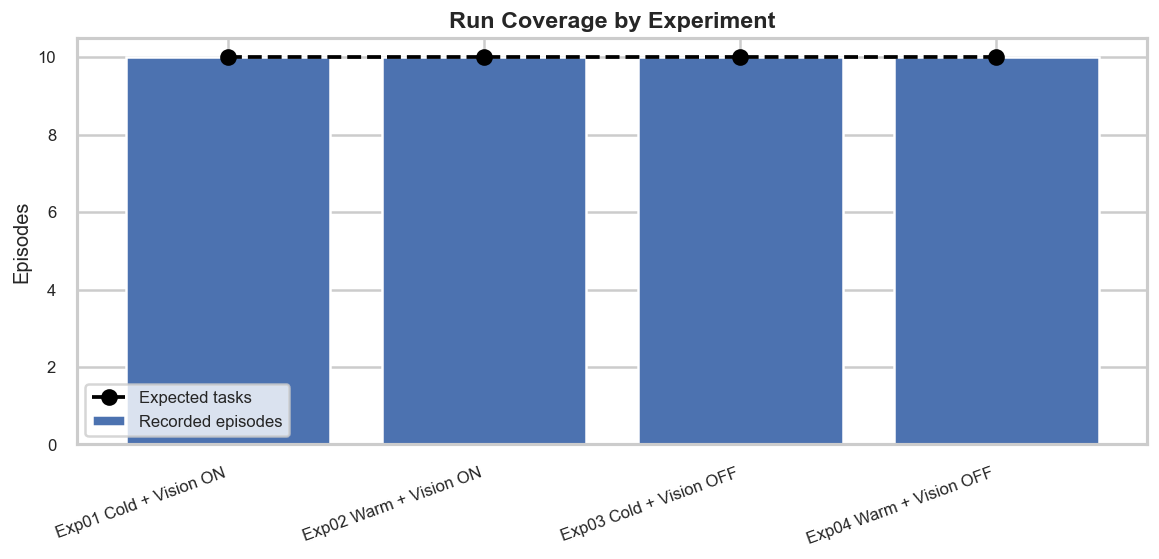

In [6]:
run_section_04_coverage(df1)


## 5) Final experiment settings table (thesis-ready)

This table summarizes the actual settings used in each experiment and provides a LaTeX export string.

In [7]:
run_section_05_settings_table(df1)


,exp_code,exp_label,max_cycles,memory_mode,memory_name,use_vision,include_invisible,keep_only_active_window_nodes
0,exp01,Exp01 Cold + Vision ON,10.0,cold (reset),thesis_mem_final_vision_on,True,False,False
1,exp02,Exp02 Warm + Vision ON,10.0,warm (reuse),thesis_mem_final_vision_on,True,False,False
2,exp03,Exp03 Cold + Vision OFF,10.0,cold (reset),thesis_mem_final_perception_tuned,False,False,False
3,exp04,Exp04 Warm + Vision OFF,10.0,warm (reuse),thesis_mem_final_perception_tuned,False,False,False


\begin{tabular}{llrllrrr}
\toprule
Experiment & exp\_label & Max cycles & Memory & memory\_name & Use vision & Include invisible & Only active window nodes \\
\midrule
exp01 & Exp01 Cold + Vision ON & 10.000000 & cold (reset) & thesis\_mem\_final\_vision\_on & True & False & False \\
exp02 & Exp02 Warm + Vision ON & 10.000000 & warm (reuse) & thesis\_mem\_final\_vision\_on & True & False & False \\
exp03 & Exp03 Cold + Vision OFF & 10.000000 & cold (reset) & thesis\_mem\_final\_perception\_tuned & False & False & False \\
exp04 & Exp04 Warm + Vision OFF & 10.000000 & warm (reuse) & thesis\_mem\_final\_perception\_tuned & False & False & False \\
\bottomrule
\end{tabular}



## 6) OSWorld success comparison

This block reports the primary benchmark outcome: task success rate by experiment.

,exp_code,exp_label,tasks,successes,success_rate
0,exp01,Exp01 Cold + Vision ON,10,7,0.7
1,exp02,Exp02 Warm + Vision ON,10,6,0.6
2,exp03,Exp03 Cold + Vision OFF,10,6,0.6
3,exp04,Exp04 Warm + Vision OFF,10,4,0.4


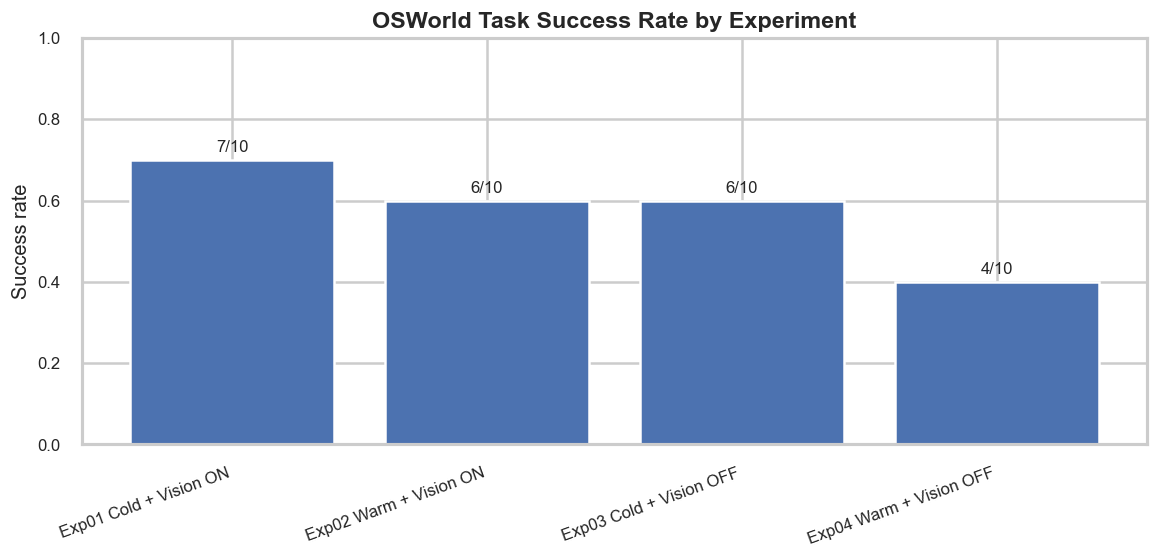

In [8]:
run_section_06_osworld_success(df1)


## 7) Chunk-level control metrics

This block compares chunk statistics: total/success/failed chunks and chunk success rate `r_c`.

,exp_code,exp_label,chunks_total,chunks_success,chunks_fail,chunk_success_rate
0,exp01,Exp01 Cold + Vision ON,6.0,3.2,2.8,0.627143
1,exp02,Exp02 Warm + Vision ON,6.6,3.1,3.5,0.620000
2,exp03,Exp03 Cold + Vision OFF,8.0,3.8,4.2,0.551071
3,exp04,Exp04 Warm + Vision OFF,6.7,3.6,3.1,0.672500


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

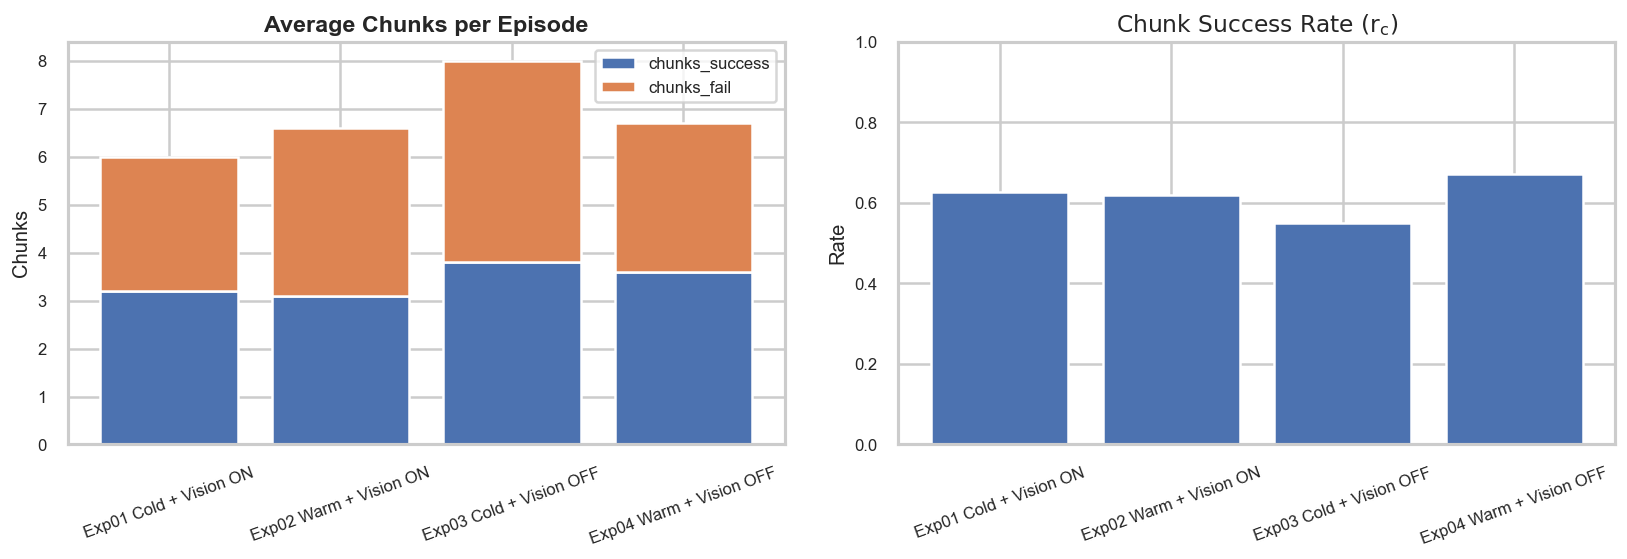

In [9]:
run_section_07_chunk_metrics(df1)


## 8) Failure dynamics inside episodes

This block visualizes first failure position and maximum consecutive chunk-failure streak, to quantify how quickly and how long the agent gets stuck.

,exp_code,exp_label,first_failure_chunk_index,max_consecutive_chunk_failures
0,exp01,Exp01 Cold + Vision ON,1.857143,2.5
1,exp02,Exp02 Warm + Vision ON,2.166667,3.0
2,exp03,Exp03 Cold + Vision OFF,2.250000,3.3
3,exp04,Exp04 Warm + Vision OFF,2.666667,2.8


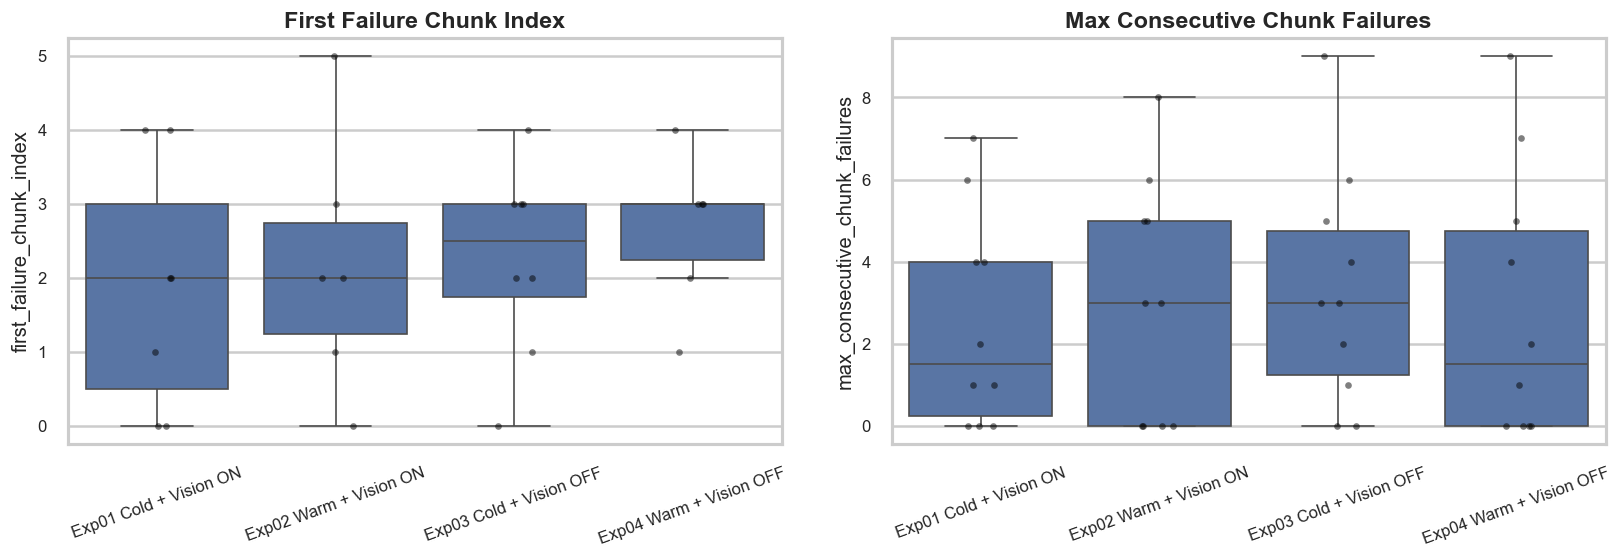

In [10]:
run_section_08_failure_dynamics(df1)


## 9) Step-level execution metrics

This block reports step totals (`N_s`), successful/failed step counts, and step success rate `r_s`.

,exp_code,exp_label,steps_total,steps_success,steps_fail,step_success_rate
0,exp01,Exp01 Cold + Vision ON,9.6,6.3,3.3,0.739502
1,exp02,Exp02 Warm + Vision ON,10.0,5.5,4.5,0.698974
2,exp03,Exp03 Cold + Vision OFF,13.1,7.7,5.4,0.650087
3,exp04,Exp04 Warm + Vision OFF,11.3,6.0,5.3,0.689633


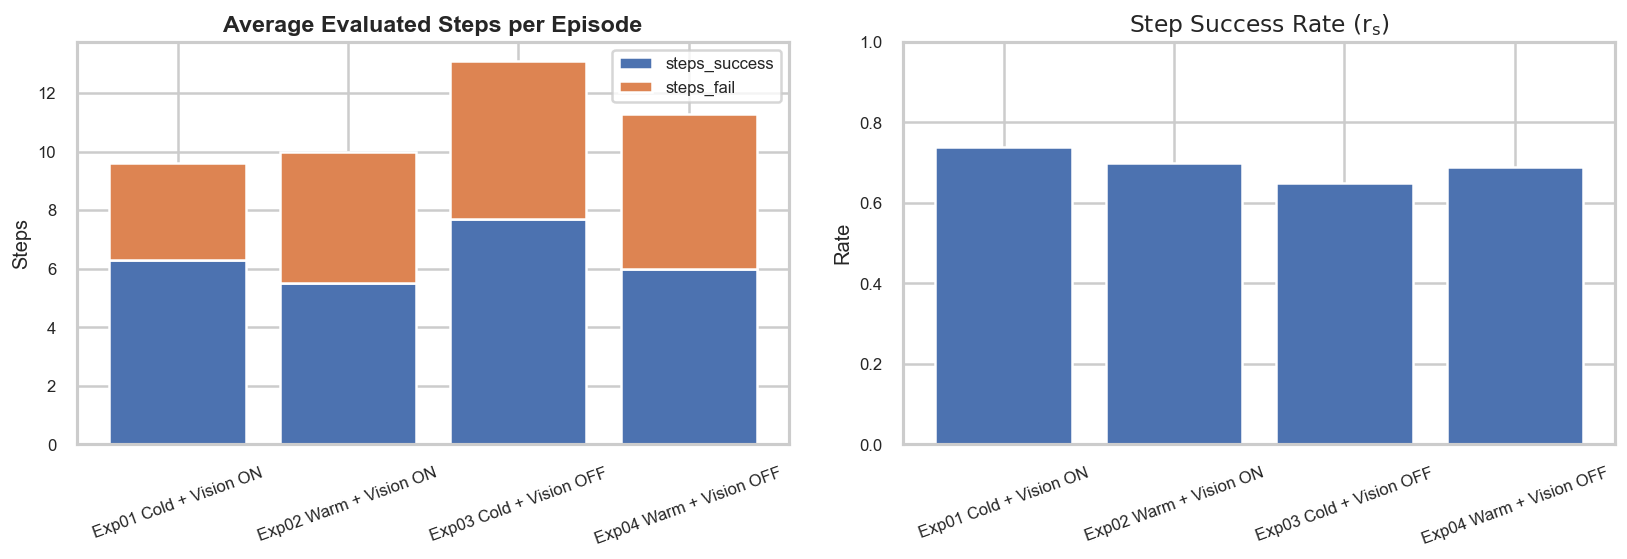

In [11]:
run_section_09_step_metrics(df1)


## 10) Action type distribution (`PYTHON` vs `WAIT`)

This block parses `action_type_counts` and compares interaction style across experiments.

action_type,exp_code,exp_label,PYTHON,WAIT,total,PYTHON_share,WAIT_share
0,exp01,Exp01 Cold + Vision ON,88.0,8.0,96.0,0.916667,0.083333
1,exp02,Exp02 Warm + Vision ON,89.0,11.0,100.0,0.890000,0.110000
2,exp03,Exp03 Cold + Vision OFF,115.0,16.0,131.0,0.877863,0.122137
3,exp04,Exp04 Warm + Vision OFF,106.0,7.0,113.0,0.938053,0.061947


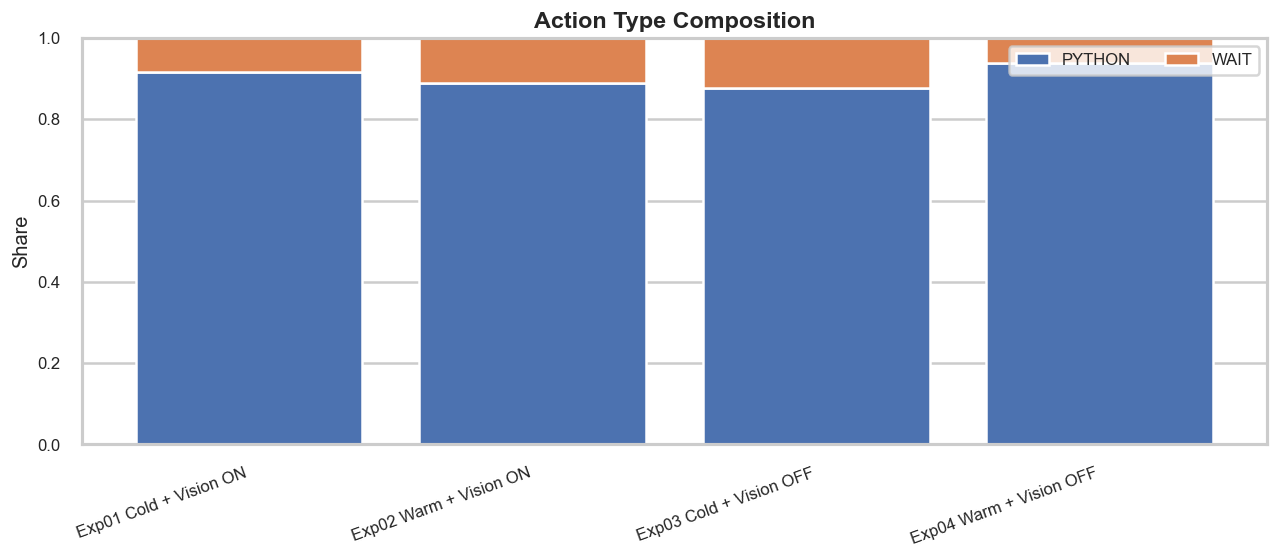

In [12]:
run_section_10_action_distribution(df1)


## 11) Timing proxies

This block compares episode duration, total planned pause `P_tot`, and average pause per step `ar{p}`.

,exp_code,exp_label,episode_duration_sec,total_planned_pause_sec,avg_pause_per_step_sec
0,exp01,Exp01 Cold + Vision ON,366.6335,33.25,3.464080
1,exp02,Exp02 Warm + Vision ON,351.8116,37.65,3.642329
2,exp03,Exp03 Cold + Vision OFF,381.5223,41.95,3.318788
3,exp04,Exp04 Warm + Vision OFF,300.4826,36.40,3.464979


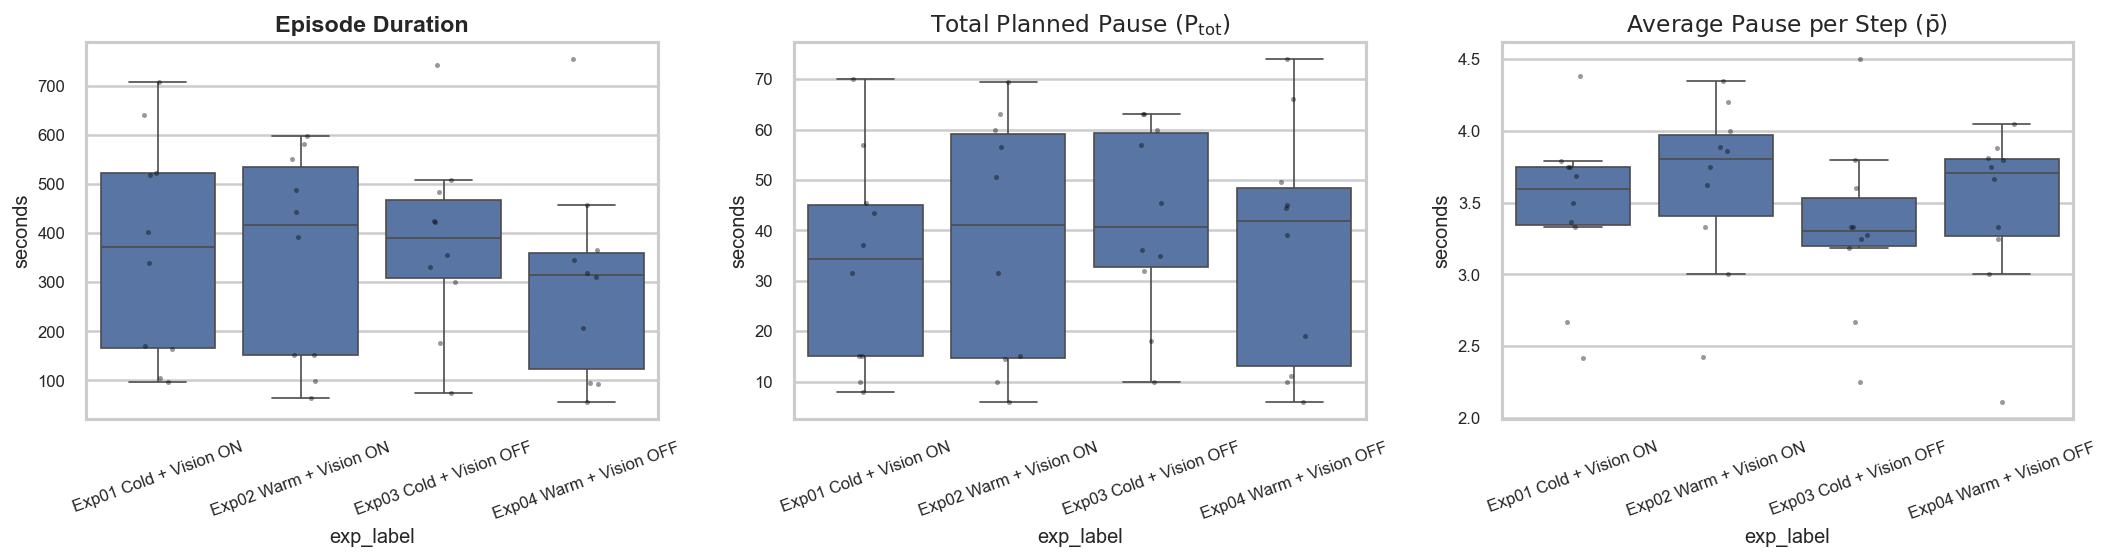

In [13]:
run_section_11_timing(df1)


## 12) Recovery dynamics

This block compares `recovery_after_fail_rate` and its components (`recoveries_after_fail_total`, `recoveries_after_fail_opportunities`).

,exp_code,exp_label,recoveries_after_fail_total,recoveries_after_fail_opportunities,recovery_after_fail_rate
0,exp01,Exp01 Cold + Vision ON,0.8,2.6,0.472789
1,exp02,Exp02 Warm + Vision ON,0.5,3.0,0.183333
2,exp03,Exp03 Cold + Vision OFF,1.1,3.8,0.370833
3,exp04,Exp04 Warm + Vision OFF,0.7,2.9,0.375000


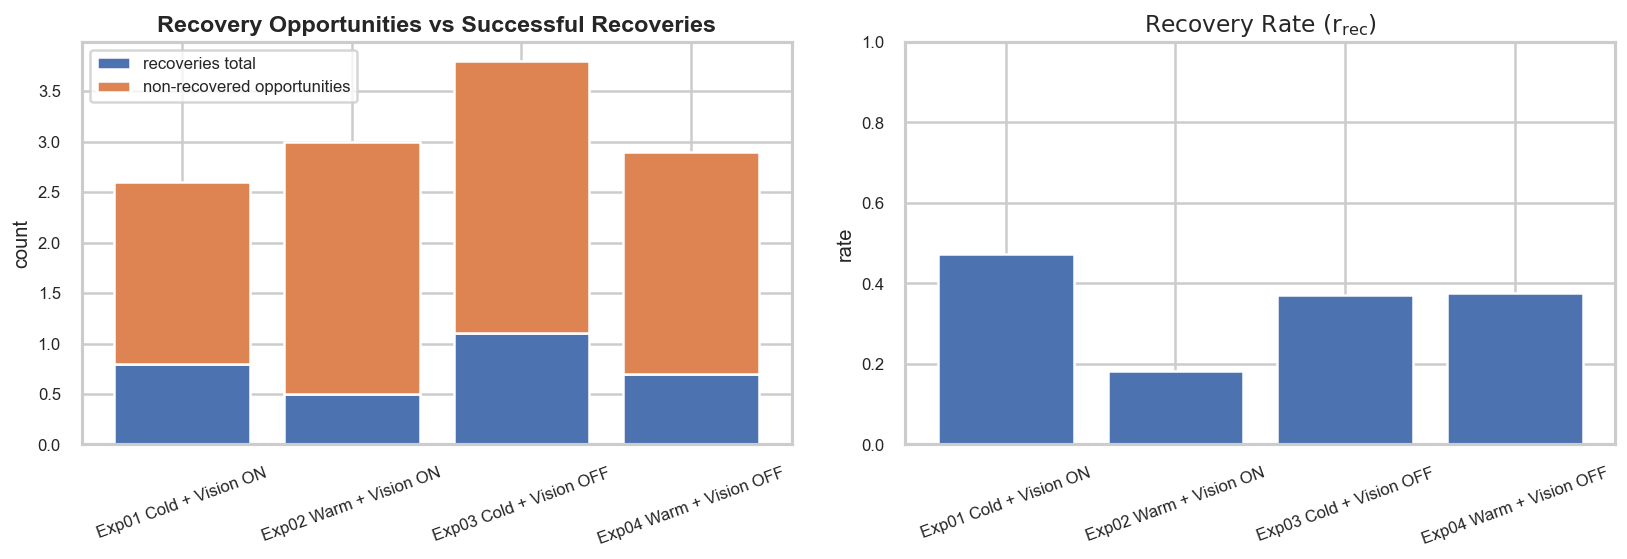

In [14]:
run_section_12_recovery(df1)


## 15) Failure type composition

This block aggregates `failure_type_counts` into a normalized stacked chart for direct comparison across experiments.

failure_type,exp_code,exp_label,ACTION_INEFFECTIVE,ENV_LIMITATION,UI_NOT_READY,WRONG_TARGET,total,ACTION_INEFFECTIVE_share,ENV_LIMITATION_share,UI_NOT_READY_share,WRONG_TARGET_share
0,exp01,Exp01 Cold + Vision ON,22.0,0.0,1.0,5.0,28.0,0.785714,0.000000,0.035714,0.178571
1,exp02,Exp02 Warm + Vision ON,29.0,1.0,0.0,5.0,35.0,0.828571,0.028571,0.000000,0.142857
2,exp03,Exp03 Cold + Vision OFF,34.0,0.0,1.0,7.0,42.0,0.809524,0.000000,0.023810,0.166667
3,exp04,Exp04 Warm + Vision OFF,25.0,0.0,1.0,5.0,31.0,0.806452,0.000000,0.032258,0.161290


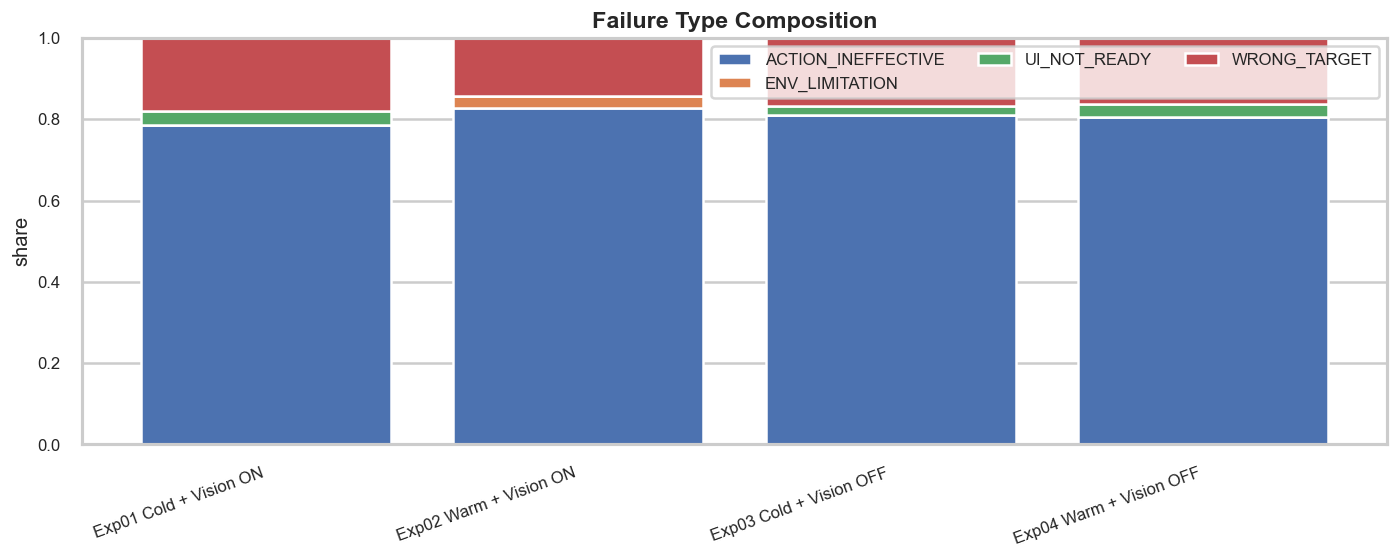

In [17]:
run_section_15_failure_types(df1)


## 16) Task-level success heatmap

This block visualizes which tasks are solved by each experiment (`1=success`, `0=fail`).

In [ ]:
run_section_16_task_heatmap(df1)
run_section_16_task_heatmap(df2)

run_section_16_task_heatmap(df3)


## 17) Final compact thesis table + LaTeX export

This final table aggregates the key metrics used in the thesis methodology and prints a LaTeX version.

In [18]:
run_section_17_final_table(df1)


,exp_code,exp_label,osworld_success_rate,chunk_success_rate_mean,step_success_rate_mean,episode_duration_sec_mean,total_planned_pause_sec_mean,avg_pause_per_step_sec_mean,recovery_after_fail_rate_mean,first_failure_chunk_index_mean,max_consecutive_chunk_failures_mean,tasks,successes
0,exp01,Exp01 Cold + Vision ON,0.7,0.627,0.740,366.634,33.25,3.464,0.473,1.857,2.5,10,7
1,exp02,Exp02 Warm + Vision ON,0.6,0.620,0.699,351.812,37.65,3.642,0.183,2.167,3.0,10,6
2,exp03,Exp03 Cold + Vision OFF,0.6,0.551,0.650,381.522,41.95,3.319,0.371,2.250,3.3,10,6
3,exp04,Exp04 Warm + Vision OFF,0.4,0.672,0.690,300.483,36.40,3.465,0.375,2.667,2.8,10,4


\begin{tabular}{llrrrrrrrrrrr}
\toprule
Experiment & Condition & osworld\_success\_rate & chunk\_success\_rate\_mean & step\_success\_rate\_mean & episode\_duration\_sec\_mean & total\_planned\_pause\_sec\_mean & avg\_pause\_per\_step\_sec\_mean & recovery\_after\_fail\_rate\_mean & first\_failure\_chunk\_index\_mean & max\_consecutive\_chunk\_failures\_mean & Episodes & Successes \\
\midrule
exp01 & Exp01 Cold + Vision ON & 0.700000 & 0.627000 & 0.740000 & 366.634000 & 33.250000 & 3.464000 & 0.473000 & 1.857000 & 2.500000 & 10 & 7 \\
exp02 & Exp02 Warm + Vision ON & 0.600000 & 0.620000 & 0.699000 & 351.812000 & 37.650000 & 3.642000 & 0.183000 & 2.167000 & 3.000000 & 10 & 6 \\
exp03 & Exp03 Cold + Vision OFF & 0.600000 & 0.551000 & 0.650000 & 381.522000 & 41.950000 & 3.319000 & 0.371000 & 2.250000 & 3.300000 & 10 & 6 \\
exp04 & Exp04 Warm + Vision OFF & 0.400000 & 0.672000 & 0.690000 & 300.483000 & 36.400000 & 3.465000 & 0.375000 & 2.667000 & 2.800000 & 10 & 4 \\
\bottomrule
\end{tabul

## 19) OSWorld Success with 95% CI

Primary benchmark metric with uncertainty bands (Wilson 95% confidence interval), plus interaction view:

- memory effect at fixed vision mode
- vision effect at fixed memory mode


,exp_code,exp_label,tasks,successes,success_rate,ci_low,ci_high
0,exp01,Exp01 Cold + Vision ON,10,7,0.7,0.396773,0.892211
1,exp02,Exp02 Warm + Vision ON,10,6,0.6,0.312670,0.831822
2,exp03,Exp03 Cold + Vision OFF,10,6,0.6,0.312670,0.831822
3,exp04,Exp04 Warm + Vision OFF,10,4,0.4,0.168178,0.687330


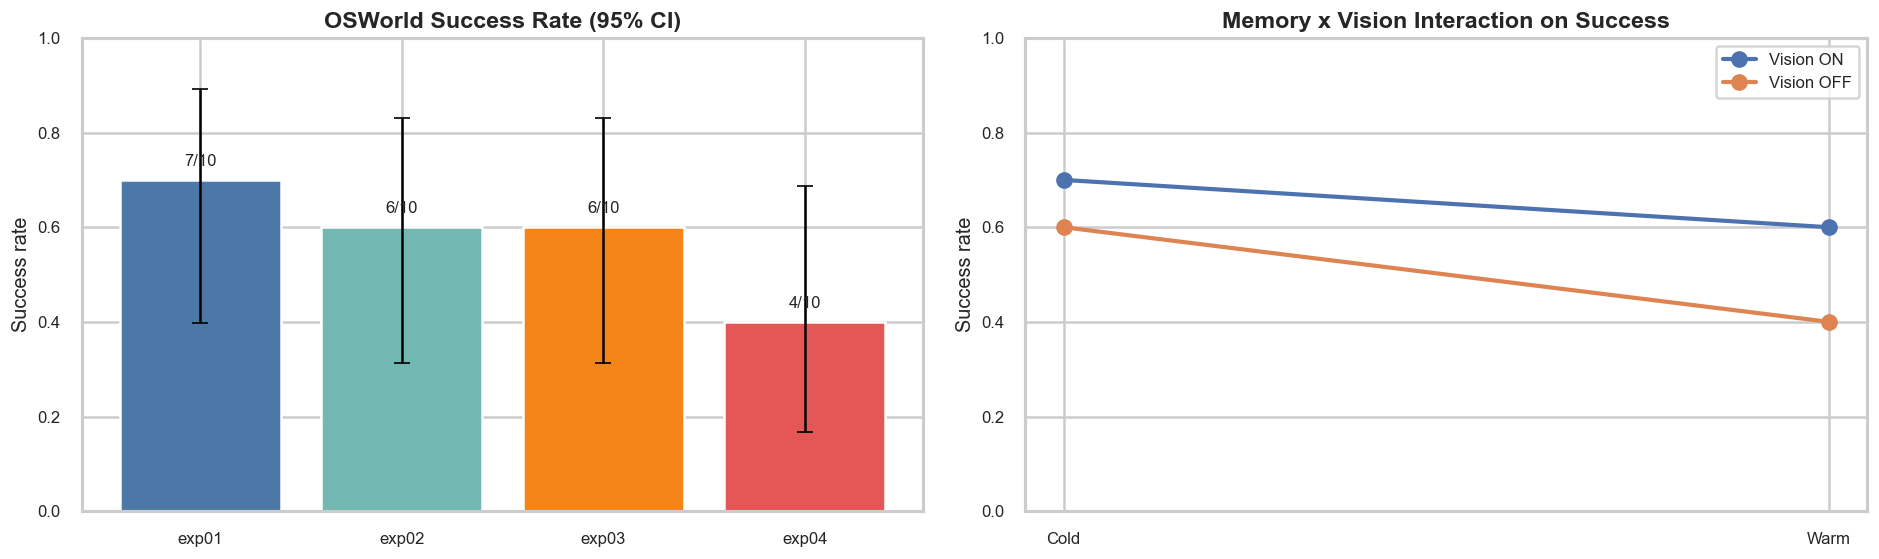

In [20]:
run_section_19_success_ci(df1)


## 20) Warm-vs-Cold Paired Task Outcomes

Task-matched comparison within each perception mode:

- same task solved by both
- solved only by cold
- solved only by warm
- failed by both


outcome,both_fail,both_success,cold_only_success
pair_label,,,
Vision OFF,4,4,2
Vision ON,3,6,1


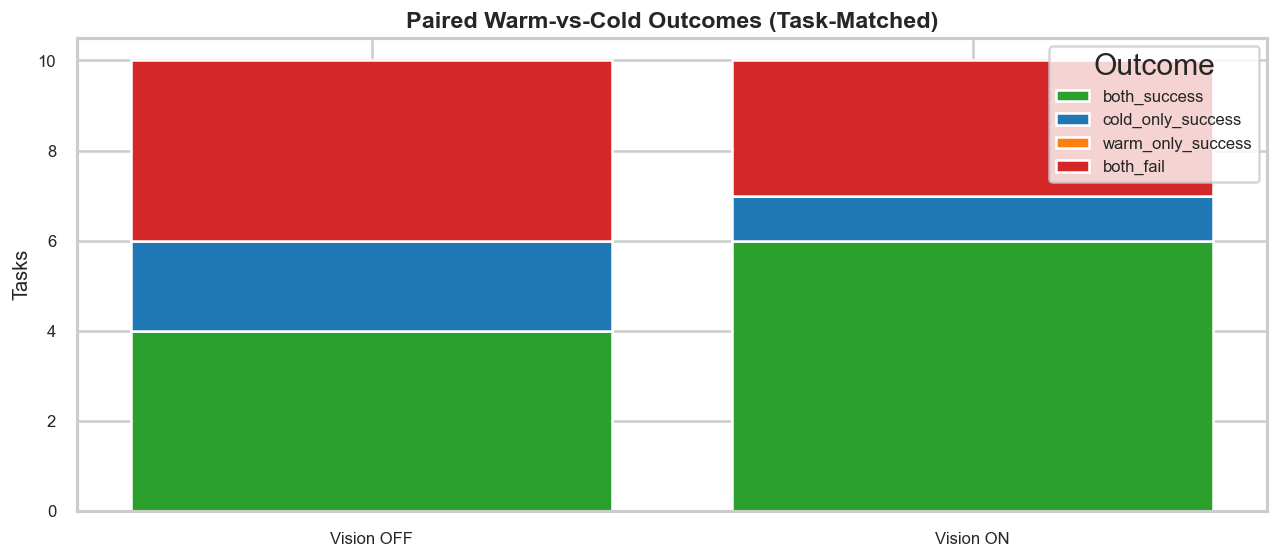

In [21]:
run_section_20_paired_outcomes(df1)


## 22) Efficiency vs Effectiveness Frontier

Trade-off plots to compare outcome quality versus resource usage:

- success rate vs average LLM requests
- success rate vs average episode duration


,exp_code,exp_label,vision_label,memory_label,success_rate,avg_llm_requests,avg_duration_sec,avg_chunk_success,avg_step_success
0,exp01,Exp01 Cold + Vision ON,Vision ON,Cold,0.7,18.7,366.6335,0.627143,0.739502
1,exp02,Exp02 Warm + Vision ON,Vision ON,Warm,0.6,20.3,351.8116,0.620000,0.698974
2,exp03,Exp03 Cold + Vision OFF,Vision OFF,Cold,0.6,24.4,381.5223,0.551071,0.650087
3,exp04,Exp04 Warm + Vision OFF,Vision OFF,Warm,0.4,20.7,300.4826,0.672500,0.689633


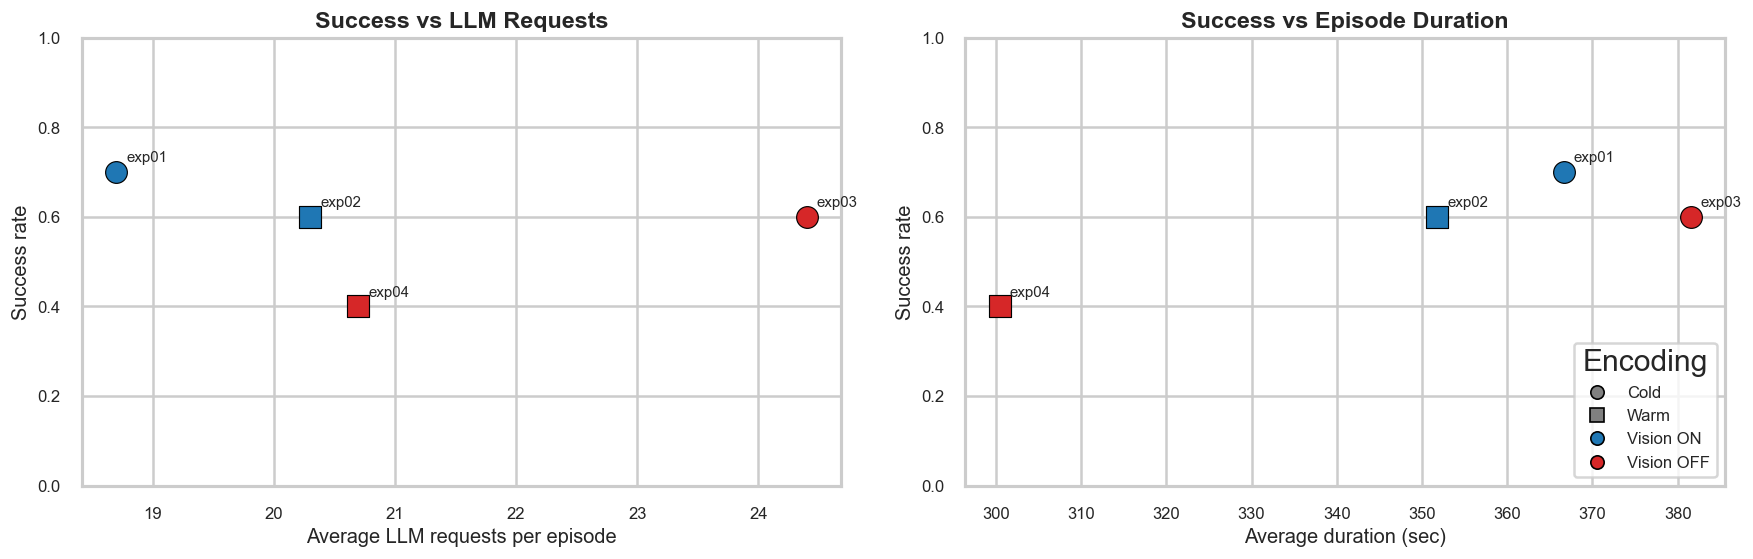

In [23]:
run_section_22_efficiency_frontier(df1)


## 23) Failure Taxonomy Heatmaps (Absolute + Normalized)

Two complementary views:

- **absolute counts** of failure types
- **row-normalized shares** per experiment


failure_type,ACTION_INEFFECTIVE,ENV_LIMITATION,UI_NOT_READY,WRONG_TARGET
exp_code,,,,
exp01,22.0,0.0,1.0,5.0
exp02,29.0,1.0,0.0,5.0
exp03,34.0,0.0,1.0,7.0
exp04,25.0,0.0,1.0,5.0


failure_type,ACTION_INEFFECTIVE,ENV_LIMITATION,UI_NOT_READY,WRONG_TARGET
exp_code,,,,
exp01,0.785714,0.000000,0.035714,0.178571
exp02,0.828571,0.028571,0.000000,0.142857
exp03,0.809524,0.000000,0.023810,0.166667
exp04,0.806452,0.000000,0.032258,0.161290


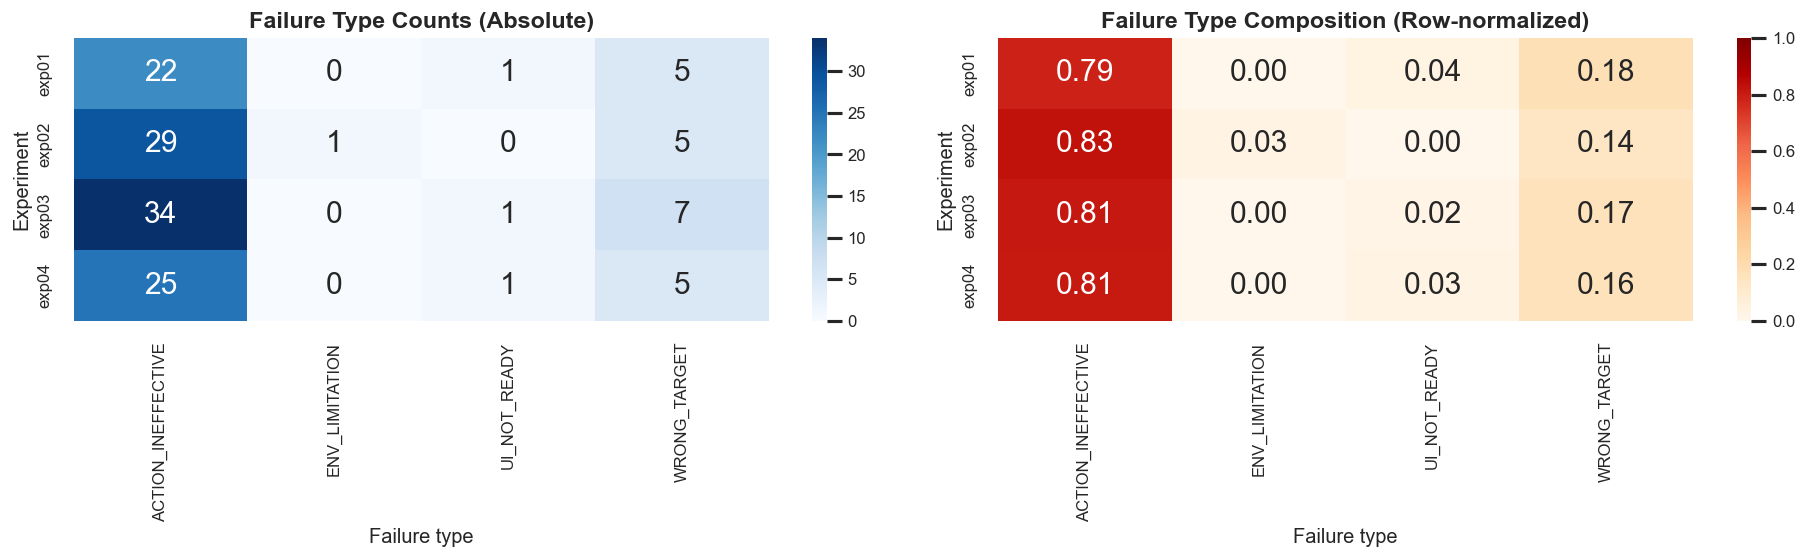

In [24]:
run_section_23_failure_heatmaps(df1)


## 24) Compact Thesis Summary (Interaction-aware)

Final compact table including outcome quality and efficiency proxies, ready for thesis text and LaTeX export.


In [25]:
run_section_24_compact_summary(df1)


,exp_code,exp_label,vision_label,memory_label,tasks,successes,osworld_success_rate,chunk_success_rate_mean,step_success_rate_mean,avg_duration_sec,avg_llm_requests,recovery_after_fail_rate_mean,max_consecutive_chunk_failures_mean
0,exp01,Exp01 Cold + Vision ON,Vision ON,Cold,10,7,0.7,0.627,0.740,366.634,18.7,0.473,2.5
1,exp02,Exp02 Warm + Vision ON,Vision ON,Warm,10,6,0.6,0.620,0.699,351.812,20.3,0.183,3.0
2,exp03,Exp03 Cold + Vision OFF,Vision OFF,Cold,10,6,0.6,0.551,0.650,381.522,24.4,0.371,3.3
3,exp04,Exp04 Warm + Vision OFF,Vision OFF,Warm,10,4,0.4,0.672,0.690,300.483,20.7,0.375,2.8


\begin{tabular}{llllrrrrrrrrr}
\toprule
Experiment & Condition & Vision & Memory & Episodes & Successes & Success rate & Chunk rate & Step rate & Avg duration (s) & Avg LLM req & Recovery rate & Max fail streak \\
\midrule
exp01 & Exp01 Cold + Vision ON & Vision ON & Cold & 10 & 7 & 0.700000 & 0.627000 & 0.740000 & 366.634000 & 18.700000 & 0.473000 & 2.500000 \\
exp02 & Exp02 Warm + Vision ON & Vision ON & Warm & 10 & 6 & 0.600000 & 0.620000 & 0.699000 & 351.812000 & 20.300000 & 0.183000 & 3.000000 \\
exp03 & Exp03 Cold + Vision OFF & Vision OFF & Cold & 10 & 6 & 0.600000 & 0.551000 & 0.650000 & 381.522000 & 24.400000 & 0.371000 & 3.300000 \\
exp04 & Exp04 Warm + Vision OFF & Vision OFF & Warm & 10 & 4 & 0.400000 & 0.672000 & 0.690000 & 300.483000 & 20.700000 & 0.375000 & 2.800000 \\
\bottomrule
\end{tabular}



## 25) Task Difficulty Profile Across Experiments

This view highlights which tasks are systematically hard/easy for the agent by aggregating success over the 4 experiments.


,task_id,success_rate,duration_mean,llm_mean,chunk_rate_mean,step_rate_mean
1,3ce045a0-877b-42aa-8d2c-b4a863336ab8,0.00,544.40700,30.00,0.300000,0.376096
6,bedcedc4-4d72-425e-ad62-21960b11fe0d,0.00,388.99350,26.00,0.516667,0.524369
7,e0df059f-28a6-4169-924f-b9623e7184cc,0.25,632.07500,23.75,0.233333,0.643895
5,b6781586-6346-41cd-935a-a6b1487918fc,0.25,510.17475,30.00,0.400000,0.463235
4,a4d98375-215b-4a4d-aee9-3d4370fccc41,0.50,403.23175,28.00,0.617857,0.628871
9,f9be0997-4b7c-45c5-b05c-4612b44a6118,0.75,213.38300,16.00,0.906250,0.886364
3,94d95f96-9699-4208-98ba-3c3119edf9c2,1.00,438.91800,28.75,0.506250,0.630994
0,28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,1.00,147.58475,10.00,1.000000,1.000000
8,ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,1.00,129.35825,10.75,0.696429,0.791667
2,5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,1.00,92.99900,7.00,1.000000,1.000000


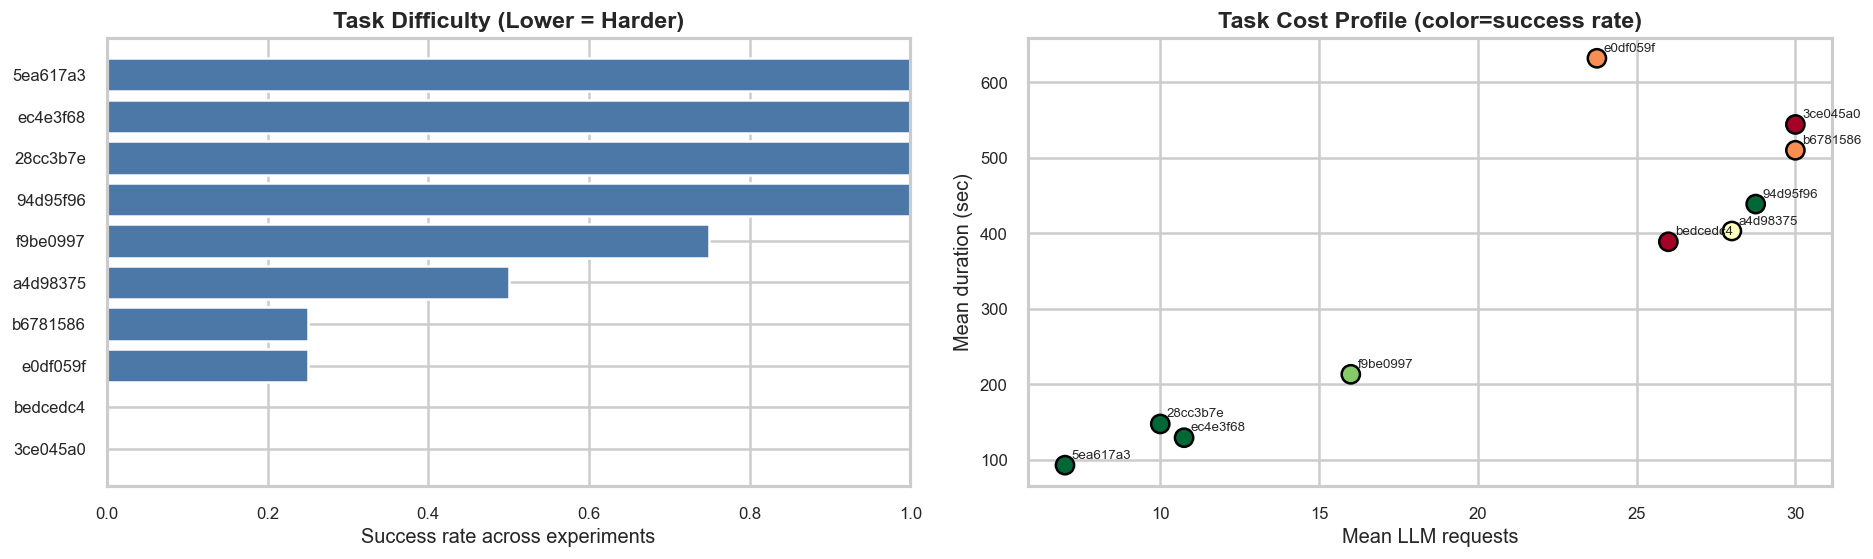

In [26]:
run_section_25_task_difficulty(df1)
